# 리텐션·재방문 분석

BigQuery `raw` 데이터셋의 합성 데이터(`_source = 'local'`)를 대상으로, 

사용자가 첫 실제 투표(`voted_at IS NOT NULL`) 이후 얼마나 다시 접속·재투표하는지를 여러 각도로 측정한다. 


D1·D7·D30, W1·W4 같은 표준 구간부터 학교 유형·학년별, 계절별·월별 코호트, 일 단위(D0~D30) 클래식 리텐션을 구한다.

In [1]:
from google.cloud import bigquery

# BigQuery 접속 객체 생성
bq = bigquery.Client(project="ping-v2-503916")

def cost(sql: str) -> float:
    """쿼리를 실행하지 않고 예상 스캔량만 확인한다."""

    cfg = bigquery.QueryJobConfig(
        dry_run=True,
        use_query_cache=False
    )

    job = bq.query(sql, job_config=cfg)
    bytes_processed = job.total_bytes_processed

    mib = bytes_processed / 2**20
    gib = bytes_processed / 2**30
    free_quota_ratio = gib / 1024 * 100

    print(f"예상 스캔량: {mib:,.3f} MiB")
    print(f"예상 스캔량: {gib:,.6f} GiB")
    print(f"월 1 TiB 무료 용량의 약 {free_quota_ratio:.8f}%")

    return gib

## D1·D7·D30 리텐션

최초 투표를 한 사용자를 기준으로, 그 다음 날부터 1·7·30일 이내에 다시 접속(`user_session`)했는지와 최초 투표 세션이 아닌 세션에서 다시 투표했는지를 각각 접속 리텐션·투표 리텐션으로 센다.

In [26]:
# D1, D7, D30
retention_d1_d7_d30_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

retention_windows AS (
  SELECT 'D1' AS retention_period, 1 AS end_day, 1 AS sort_order
  UNION ALL
  SELECT 'D7', 7, 2
  UNION ALL
  SELECT 'D30', 30, 3
),

-- 탈퇴하지 않은 합성 데이터 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Acquisition과 Activation을 충족한 사용자
activated_users AS (
  SELECT
    u.user_id,
    f.first_vote_at,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 첫 투표 다음 날 이후 최초 재접속일
first_login_return AS (
  SELECT
    a.user_id,
    MIN(
      DATE(s.started_at, 'Asia/Seoul')
    ) AS first_login_return_date
  FROM activated_users AS a
  JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = a.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
  WHERE s.started_at IS NOT NULL
    AND DATE(s.started_at, 'Asia/Seoul') > a.first_vote_date
  GROUP BY a.user_id
),

-- 첫 투표 세션이 아닌 새로운 세션에서의 최초 재투표일
first_vote_return AS (
  SELECT
    a.user_id,
    MIN(
      DATE(v.voted_at, 'Asia/Seoul')
    ) AS first_vote_return_date
  FROM activated_users AS a
  JOIN actual_votes AS v
    ON v.user_id = a.user_id
  WHERE v.session_id != a.first_vote_session_id

    -- 첫 투표 당일 행동은 리텐션에서 제외
    AND DATE(v.voted_at, 'Asia/Seoul') > a.first_vote_date

  GROUP BY a.user_id
)

SELECT
  w.retention_period,

  -- 각 기간을 끝까지 관찰할 수 있었던 사용자
  COUNTIF(
    a.first_vote_date
      <= DATE_SUB(
           p.data_end_date,
           INTERVAL w.end_day DAY
         )
  ) AS eligible_user_count,

  -- 접속 리텐션
  COUNTIF(
    a.first_vote_date
      <= DATE_SUB(
           p.data_end_date,
           INTERVAL w.end_day DAY
         )
    AND DATE_DIFF(
          l.first_login_return_date,
          a.first_vote_date,
          DAY
        ) BETWEEN 1 AND w.end_day
  ) AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(
        a.first_vote_date
          <= DATE_SUB(
               p.data_end_date,
               INTERVAL w.end_day DAY
             )
        AND DATE_DIFF(
              l.first_login_return_date,
              a.first_vote_date,
              DAY
            ) BETWEEN 1 AND w.end_day
      ),
      COUNTIF(
        a.first_vote_date
          <= DATE_SUB(
               p.data_end_date,
               INTERVAL w.end_day DAY
             )
      )
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  -- 투표 리텐션: 힌트 구매 제외
  COUNTIF(
    a.first_vote_date
      <= DATE_SUB(
           p.data_end_date,
           INTERVAL w.end_day DAY
         )
    AND DATE_DIFF(
          v.first_vote_return_date,
          a.first_vote_date,
          DAY
        ) BETWEEN 1 AND w.end_day
  ) AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(
        a.first_vote_date
          <= DATE_SUB(
               p.data_end_date,
               INTERVAL w.end_day DAY
             )
        AND DATE_DIFF(
              v.first_vote_return_date,
              a.first_vote_date,
              DAY
            ) BETWEEN 1 AND w.end_day
      ),
      COUNTIF(
        a.first_vote_date
          <= DATE_SUB(
               p.data_end_date,
               INTERVAL w.end_day DAY
             )
      )
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM activated_users AS a
CROSS JOIN params AS p
CROSS JOIN retention_windows AS w
LEFT JOIN first_login_return AS l
  ON a.user_id = l.user_id
LEFT JOIN first_vote_return AS v
  ON a.user_id = v.user_id

GROUP BY
  w.retention_period,
  w.end_day,
  w.sort_order

ORDER BY w.sort_order
"""

In [27]:
cost(retention_d1_d7_d30_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [28]:
df_retention = bq.query(
    retention_d1_d7_d30_sql
).to_dataframe()

display(df_retention)

,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,D1,14843,6725,45.31,6293,42.40
1,D7,14661,8542,58.26,8308,56.67
2,D30,14010,8329,59.45,8120,57.96


In [30]:
# D1 → D7 → D30 순서 정렬
period_order = ["D1", "D7", "D30"]

formatted_df = (
    df_retention
    .set_index("retention_period")
    .reindex(period_order)
    .reset_index()
)

for _, row in formatted_df.iterrows():
    print(f"[{row['retention_period']}]")

    print(
        f"관찰 가능 사용자: "
        f"{int(row['eligible_user_count']):,}명"
    )

    print(
        f"접속 리텐션: "
        f"{int(row['login_retained_user_count']):,}명 "
        f"({float(row['login_retention_rate_percent']):.2f}%)"
    )

    print(
        f"투표 리텐션: "
        f"{int(row['vote_retained_user_count']):,}명 "
        f"({float(row['vote_retention_rate_percent']):.2f}%)"
    )

    print()

[D1]
관찰 가능 사용자: 14,843명
접속 리텐션: 6,725명 (45.31%)
투표 리텐션: 6,293명 (42.40%)

[D7]
관찰 가능 사용자: 14,661명
접속 리텐션: 8,542명 (58.26%)
투표 리텐션: 8,308명 (56.67%)

[D30]
관찰 가능 사용자: 14,010명
접속 리텐션: 8,329명 (59.45%)
투표 리텐션: 8,120명 (57.96%)



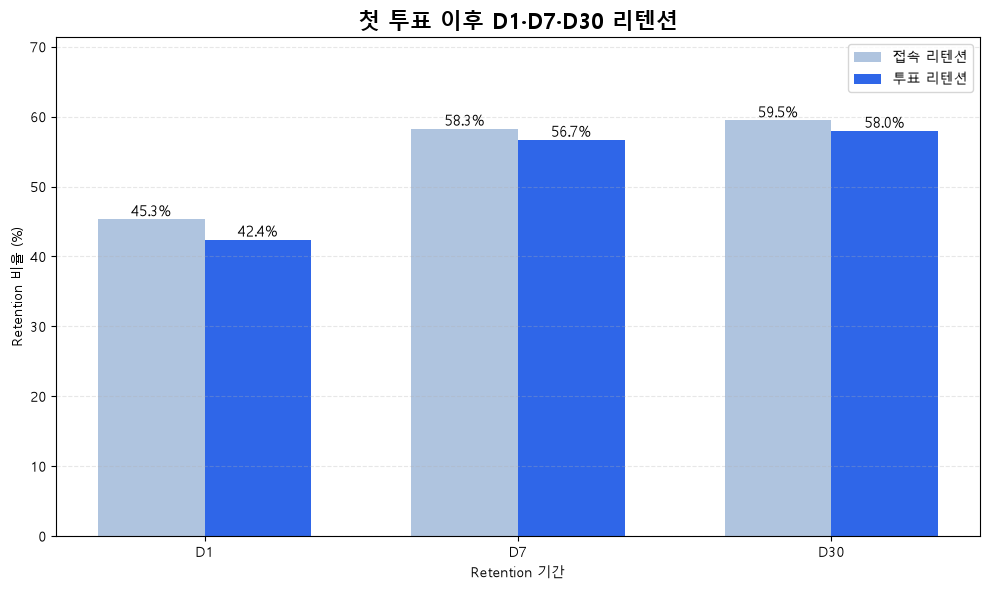

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

periods = df_retention["retention_period"]
login_rates = df_retention["login_retention_rate_percent"]
vote_rates = df_retention["vote_retention_rate_percent"]

x = np.arange(len(periods))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 6))

login_bars = ax.bar(
    x - width / 2,
    login_rates,
    width,
    label="접속 리텐션",
    color="#AFC4DF"
)

vote_bars = ax.bar(
    x + width / 2,
    vote_rates,
    width,
    label="투표 리텐션",
    color="#2F66E8"
)

for bar, value in zip(login_bars, login_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

for bar, value in zip(vote_bars, vote_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "첫 투표 이후 D1·D7·D30 리텐션",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Retention 기간")
ax.set_ylabel("Retention 비율 (%)")
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.set_ylim(
    0,
    max(login_rates.max(), vote_rates.max()) * 1.2
)

plt.tight_layout()
plt.show()

## W1·W4 주간 리텐션

같은 activation 기준으로, 관찰 구간을 1~7일(W1)·22~28일(W4)로 바꿔 그 구간 안에 재접속·재투표가 한 번이라도 있었는지를 본다.

In [32]:
# W1, W4
retention_w1_w4_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

retention_windows AS (
  SELECT
    'W1' AS retention_period,
    1 AS start_day,
    7 AS end_day,
    1 AS sort_order

  UNION ALL

  SELECT
    'W4',
    22,
    28,
    2
),

-- 탈퇴하지 않은 합성 데이터 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Acquisition과 Activation을 충족한 사용자
activated_users AS (
  SELECT
    u.user_id,
    f.first_vote_at,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 첫 투표 이후 재접속한 날짜
login_return_days AS (
  SELECT DISTINCT
    a.user_id,
    DATE(s.started_at, 'Asia/Seoul') AS activity_date
  FROM activated_users AS a
  JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = a.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
  WHERE s.started_at IS NOT NULL
    AND DATE(s.started_at, 'Asia/Seoul') > a.first_vote_date
),

-- 첫 투표 세션 이후 다른 세션에서 재투표한 날짜
vote_return_days AS (
  SELECT DISTINCT
    a.user_id,
    DATE(v.voted_at, 'Asia/Seoul') AS activity_date
  FROM activated_users AS a
  JOIN actual_votes AS v
    ON v.user_id = a.user_id
  WHERE v.session_id != a.first_vote_session_id
    AND DATE(v.voted_at, 'Asia/Seoul') > a.first_vote_date
),

-- 각 기간을 끝까지 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    a.user_id,
    a.first_vote_date,
    w.retention_period,
    w.start_day,
    w.end_day,
    w.sort_order
  FROM activated_users AS a
  CROSS JOIN retention_windows AS w
  CROSS JOIN params AS p
  WHERE a.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL w.end_day DAY
       )
),

-- 사용자별 접속 리텐션 여부
login_flags AS (
  SELECT
    e.user_id,
    e.retention_period,
    MAX(
      CASE
        WHEN l.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS login_retained
  FROM eligible_users AS e
  LEFT JOIN login_return_days AS l
    ON l.user_id = e.user_id
   AND DATE_DIFF(
         l.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day
  GROUP BY
    e.user_id,
    e.retention_period
),

-- 사용자별 투표 리텐션 여부
vote_flags AS (
  SELECT
    e.user_id,
    e.retention_period,
    MAX(
      CASE
        WHEN v.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS vote_retained
  FROM eligible_users AS e
  LEFT JOIN vote_return_days AS v
    ON v.user_id = e.user_id
   AND DATE_DIFF(
         v.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day
  GROUP BY
    e.user_id,
    e.retention_period
)

SELECT
  e.retention_period,
  COUNT(*) AS eligible_user_count,

  COUNTIF(l.login_retained = 1)
    AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(l.login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  COUNTIF(v.vote_retained = 1)
    AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM eligible_users AS e
JOIN login_flags AS l
  ON e.user_id = l.user_id
 AND e.retention_period = l.retention_period
JOIN vote_flags AS v
  ON e.user_id = v.user_id
 AND e.retention_period = v.retention_period

GROUP BY
  e.retention_period,
  e.sort_order

ORDER BY e.sort_order
"""

In [33]:
cost(retention_w1_w4_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [34]:
df_weekly_retention = bq.query(
    retention_w1_w4_sql
).to_dataframe()

display(df_weekly_retention)

,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,W1,14661,8542,58.26,8308,56.67
1,W4,14057,3011,21.42,2980,21.20


In [35]:
period_order = ["W1", "W4"]

formatted_weekly_df = (
    df_weekly_retention
    .set_index("retention_period")
    .reindex(period_order)
    .reset_index()
)

for _, row in formatted_weekly_df.iterrows():
    print(f"[{row['retention_period']}]")

    print(
        f"관찰 가능 사용자: "
        f"{int(row['eligible_user_count']):,}명"
    )

    print(
        f"접속 리텐션: "
        f"{int(row['login_retained_user_count']):,}명 "
        f"({float(row['login_retention_rate_percent']):.2f}%)"
    )

    print(
        f"투표 리텐션: "
        f"{int(row['vote_retained_user_count']):,}명 "
        f"({float(row['vote_retention_rate_percent']):.2f}%)"
    )

    print()

[W1]
관찰 가능 사용자: 14,661명
접속 리텐션: 8,542명 (58.26%)
투표 리텐션: 8,308명 (56.67%)

[W4]
관찰 가능 사용자: 14,057명
접속 리텐션: 3,011명 (21.42%)
투표 리텐션: 2,980명 (21.20%)



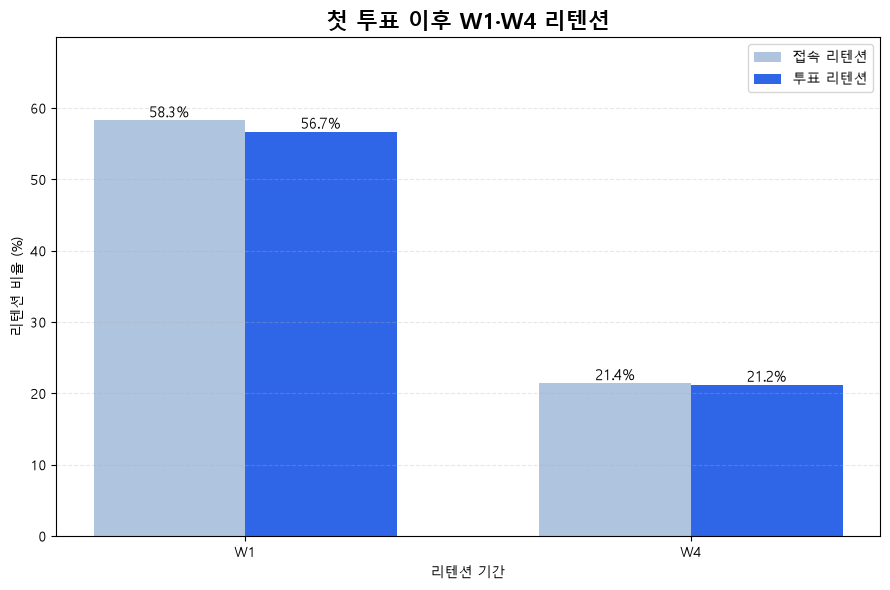

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

periods = df_weekly_retention["retention_period"]
login_rates = df_weekly_retention["login_retention_rate_percent"]
vote_rates = df_weekly_retention["vote_retention_rate_percent"]

x = np.arange(len(periods))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 6))

login_bars = ax.bar(
    x - width / 2,
    login_rates,
    width,
    label="접속 리텐션",
    color="#AFC4DF"
)

vote_bars = ax.bar(
    x + width / 2,
    vote_rates,
    width,
    label="투표 리텐션",
    color="#2F66E8"
)

for bar, value in zip(login_bars, login_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

for bar, value in zip(vote_bars, vote_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "첫 투표 이후 W1·W4 리텐션",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("리텐션 기간")
ax.set_ylabel("리텐션 비율 (%)")
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

max_rate = max(login_rates.max(), vote_rates.max())
ax.set_ylim(0, max_rate * 1.2)

plt.tight_layout()
plt.show()

## 10문항 완료 여부에 따른 재방문율

10문항 완료/미완료 두 그룹의 W1·W4 접속·투표 재방문율을 비교한다.

In [37]:
# 투표 완료 사용자와 미완료 사용자의 재방문율
completion_revisit_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

retention_windows AS (
  SELECT
    'W1' AS retention_period,
    1 AS start_day,
    7 AS end_day,
    1 AS sort_order

  UNION ALL

  SELECT
    'W4',
    22,
    28,
    2
),

-- 탈퇴하지 않은 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.id AS vote_item_id,
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Activation 사용자
activated_users AS (
  SELECT
    u.user_id,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 실제 10문항을 완료한 세션
completed_sessions AS (
  SELECT
    vs.user_id,
    vs.id AS session_id
  FROM `ping-v2-503916.raw.vote_session` AS vs
  JOIN actual_votes AS v
    ON v.session_id = vs.id
   AND v.user_id = vs.user_id
  WHERE vs._source = 'local'
    AND vs._deleted_at IS NULL
    AND vs.status = 'COMPLETED'
    AND vs.completed_at IS NOT NULL
    AND vs.item_count = 10
  GROUP BY
    vs.user_id,
    vs.id
  HAVING COUNT(DISTINCT v.vote_item_id) >= 10
),

-- 사용자 단위 완료·미완료 구분
user_segments AS (
  SELECT
    a.user_id,
    a.first_vote_date,
    a.first_vote_session_id,

    CASE
      WHEN c.user_id IS NOT NULL THEN '10문항 완료'
      ELSE '10문항 미완료'
    END AS completion_group

  FROM activated_users AS a

  LEFT JOIN (
    SELECT DISTINCT user_id
    FROM completed_sessions
  ) AS c
    ON a.user_id = c.user_id
),

-- 재접속 날짜
login_return_days AS (
  SELECT DISTINCT
    u.user_id,
    DATE(s.started_at, 'Asia/Seoul') AS activity_date
  FROM user_segments AS u
  JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = u.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
  WHERE s.started_at IS NOT NULL
    AND DATE(s.started_at, 'Asia/Seoul') > u.first_vote_date
),

-- 다른 투표 세션에서 재투표한 날짜
vote_return_days AS (
  SELECT DISTINCT
    u.user_id,
    DATE(v.voted_at, 'Asia/Seoul') AS activity_date
  FROM user_segments AS u
  JOIN actual_votes AS v
    ON v.user_id = u.user_id
  WHERE v.session_id != u.first_vote_session_id
    AND DATE(v.voted_at, 'Asia/Seoul') > u.first_vote_date
),

-- 각 구간을 끝까지 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    u.user_id,
    u.first_vote_date,
    u.completion_group,
    w.retention_period,
    w.start_day,
    w.end_day,
    w.sort_order
  FROM user_segments AS u
  CROSS JOIN retention_windows AS w
  CROSS JOIN params AS p
  WHERE u.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL w.end_day DAY
       )
),

-- 사용자별 접속 재방문 여부
login_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN l.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS login_retained

  FROM eligible_users AS e
  LEFT JOIN login_return_days AS l
    ON l.user_id = e.user_id
   AND DATE_DIFF(
         l.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
),

-- 사용자별 투표 재방문 여부
vote_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN v.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS vote_retained

  FROM eligible_users AS e
  LEFT JOIN vote_return_days AS v
    ON v.user_id = e.user_id
   AND DATE_DIFF(
         v.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
)

SELECT
  e.retention_period,
  e.completion_group,

  COUNT(*) AS eligible_user_count,

  COUNTIF(l.login_retained = 1)
    AS login_return_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(l.login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_return_rate_percent,

  COUNTIF(v.vote_retained = 1)
    AS vote_return_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_return_rate_percent

FROM eligible_users AS e
JOIN login_flags AS l
  ON e.user_id = l.user_id
 AND e.retention_period = l.retention_period
JOIN vote_flags AS v
  ON e.user_id = v.user_id
 AND e.retention_period = v.retention_period

GROUP BY
  e.retention_period,
  e.completion_group,
  e.sort_order

ORDER BY
  e.sort_order,
  CASE e.completion_group
    WHEN '10문항 완료' THEN 1
    ELSE 2
  END
"""

In [38]:
cost(completion_revisit_sql)

예상 스캔량: 587.060 MiB
예상 스캔량: 0.573301 GiB
월 1 TiB 무료 용량의 약 0.05598641%


0.5733008729293942

In [39]:
df_completion_revisit = bq.query(
    completion_revisit_sql
).to_dataframe()

display(df_completion_revisit)

,retention_period,completion_group,eligible_user_count,login_return_user_count,login_return_rate_percent,vote_return_user_count,vote_return_rate_percent
0,W1,10문항 완료,10863,7851,72.27,7738,71.23
1,W1,10문항 미완료,3798,691,18.19,570,15.01
2,W4,10문항 완료,10454,3005,28.74,2975,28.46
3,W4,10문항 미완료,3603,6,0.17,5,0.14


In [40]:
period_order = ["W1", "W4"]
group_order = ["10문항 완료", "10문항 미완료"]

formatted_df = df_completion_revisit.copy()

formatted_df["period_order"] = (
    formatted_df["retention_period"]
    .map({period: index for index, period in enumerate(period_order)})
)

formatted_df["group_order"] = (
    formatted_df["completion_group"]
    .map({group: index for index, group in enumerate(group_order)})
)

formatted_df = formatted_df.sort_values(
    ["period_order", "group_order"]
)

for period in period_order:
    print(f"[{period}]")

    period_df = formatted_df[
        formatted_df["retention_period"] == period
    ]

    for _, row in period_df.iterrows():
        print(f"{row['completion_group']} 사용자")

        print(
            f"- 관찰 가능 사용자: "
            f"{int(row['eligible_user_count']):,}명"
        )

        print(
            f"- 접속 재방문: "
            f"{int(row['login_return_user_count']):,}명 "
            f"({float(row['login_return_rate_percent']):.2f}%)"
        )

        print(
            f"- 투표 재방문: "
            f"{int(row['vote_return_user_count']):,}명 "
            f"({float(row['vote_return_rate_percent']):.2f}%)"
        )

        print()

    print()

[W1]
10문항 완료 사용자
- 관찰 가능 사용자: 10,863명
- 접속 재방문: 7,851명 (72.27%)
- 투표 재방문: 7,738명 (71.23%)

10문항 미완료 사용자
- 관찰 가능 사용자: 3,798명
- 접속 재방문: 691명 (18.19%)
- 투표 재방문: 570명 (15.01%)


[W4]
10문항 완료 사용자
- 관찰 가능 사용자: 10,454명
- 접속 재방문: 3,005명 (28.74%)
- 투표 재방문: 2,975명 (28.46%)

10문항 미완료 사용자
- 관찰 가능 사용자: 3,603명
- 접속 재방문: 6명 (0.17%)
- 투표 재방문: 5명 (0.14%)




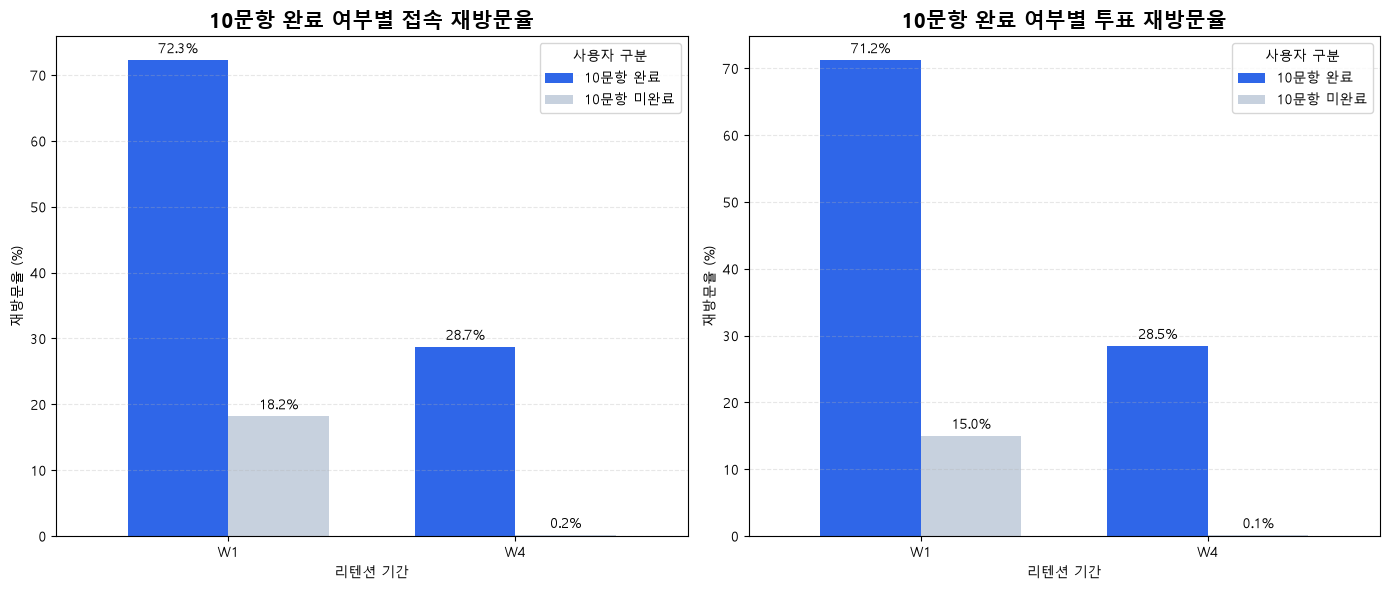

In [41]:
import matplotlib.pyplot as plt
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

period_order = ["W1", "W4"]
group_order = ["10문항 완료", "10문항 미완료"]

login_pivot = (
    df_completion_revisit
    .pivot(
        index="retention_period",
        columns="completion_group",
        values="login_return_rate_percent"
    )
    .reindex(index=period_order, columns=group_order)
)

vote_pivot = (
    df_completion_revisit
    .pivot(
        index="retention_period",
        columns="completion_group",
        values="vote_return_rate_percent"
    )
    .reindex(index=period_order, columns=group_order)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

login_pivot.plot(
    kind="bar",
    ax=axes[0],
    color=["#2F66E8", "#C7D1DE"],
    width=0.7
)

vote_pivot.plot(
    kind="bar",
    ax=axes[1],
    color=["#2F66E8", "#C7D1DE"],
    width=0.7
)

titles = [
    "10문항 완료 여부별 접속 재방문율",
    "10문항 완료 여부별 투표 재방문율"
]

for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlabel("리텐션 기간")
    ax.set_ylabel("재방문율 (%)")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(title="사용자 구분")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=10
        )

plt.tight_layout()
plt.show()

## 첫 투표 후 30일간 사용자당 활동 일수

첫 투표 후 30일을 전부 관찰할 수 있는 사용자에 대해, 30일간 접속일수(`login_active_days_30d`)와 재투표일수(`vote_active_days_30d`)를 세어 평균·중앙값·활동 0일 사용자 비율을 계산한다.

In [ ]:
# 사용자당 활동 일수
activity_days_30d_sql = """
WITH params AS (
  SELECT
    DATE '2026-07-23' AS data_end_date,
    30 AS observation_days
),

-- 탈퇴하지 않은 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Acquisition과 Activation 충족 사용자
activated_users AS (
  SELECT
    u.user_id,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 첫 투표 이후 30일을 전부 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    a.user_id,
    a.first_vote_date,
    a.first_vote_session_id
  FROM activated_users AS a
  CROSS JOIN params AS p
  WHERE a.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL p.observation_days DAY
       )
),

-- 사용자별 접속 활동 일수
login_activity AS (
  SELECT
    e.user_id,

    COUNT(
      DISTINCT DATE(s.started_at, 'Asia/Seoul')
    ) AS login_active_days_30d

  FROM eligible_users AS e
  LEFT JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = e.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
   AND s.started_at IS NOT NULL
   AND DATE_DIFF(
         DATE(s.started_at, 'Asia/Seoul'),
         e.first_vote_date,
         DAY
       ) BETWEEN 1 AND 30

  GROUP BY e.user_id
),

-- 사용자별 투표 활동 일수
vote_activity AS (
  SELECT
    e.user_id,

    COUNT(
      DISTINCT DATE(v.voted_at, 'Asia/Seoul')
    ) AS vote_active_days_30d

  FROM eligible_users AS e
  LEFT JOIN actual_votes AS v
    ON v.user_id = e.user_id

    -- 최초 투표 세션의 나머지 투표 제외
   AND v.session_id != e.first_vote_session_id

   AND DATE_DIFF(
         DATE(v.voted_at, 'Asia/Seoul'),
         e.first_vote_date,
         DAY
       ) BETWEEN 1 AND 30

  GROUP BY e.user_id
)

SELECT
  e.user_id,
  e.first_vote_date,

  COALESCE(
    l.login_active_days_30d,
    0
  ) AS login_active_days_30d,

  COALESCE(
    v.vote_active_days_30d,
    0
  ) AS vote_active_days_30d

FROM eligible_users AS e
LEFT JOIN login_activity AS l
  ON e.user_id = l.user_id
LEFT JOIN vote_activity AS v
  ON e.user_id = v.user_id

ORDER BY e.user_id
"""

In [43]:
cost(activity_days_30d_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [44]:
df_activity_days = bq.query(
    activity_days_30d_sql
).to_dataframe()

display(df_activity_days.head())

,user_id,first_vote_date,login_active_days_30d,vote_active_days_30d
0,1,2025-09-03,0,0
1,2,2025-09-01,29,27
2,3,2025-09-01,23,21
3,4,2025-09-01,23,21
4,5,2025-09-04,0,0


In [45]:
import pandas as pd

eligible_user_count = len(df_activity_days)

activity_summary = pd.DataFrame({
    "activity_type": [
        "접속 활동",
        "투표 활동"
    ],
    "average_active_days": [
        df_activity_days["login_active_days_30d"].mean(),
        df_activity_days["vote_active_days_30d"].mean()
    ],
    "median_active_days": [
        df_activity_days["login_active_days_30d"].median(),
        df_activity_days["vote_active_days_30d"].median()
    ],
    "zero_day_user_count": [
        (df_activity_days["login_active_days_30d"] == 0).sum(),
        (df_activity_days["vote_active_days_30d"] == 0).sum()
    ]
})

activity_summary["zero_day_user_rate_percent"] = (
    activity_summary["zero_day_user_count"]
    / eligible_user_count
    * 100
).round(2)

activity_summary["average_active_days"] = (
    activity_summary["average_active_days"].round(2)
)

activity_summary["median_active_days"] = (
    activity_summary["median_active_days"].round(2)
)

display(activity_summary)

,activity_type,average_active_days,median_active_days,zero_day_user_count,zero_day_user_rate_percent
0,접속 활동,6.90,1.0,5681,40.55
1,투표 활동,6.57,1.0,5890,42.04


In [46]:
print(f"30일 관찰 가능 사용자: {eligible_user_count:,}명")
print()

for _, row in activity_summary.iterrows():
    print(f"[{row['activity_type']}]")

    print(
        f"사용자당 평균 활동 일수: "
        f"{row['average_active_days']:.2f}일"
    )

    print(
        f"중앙값: "
        f"{row['median_active_days']:.2f}일"
    )

    print(
        f"활동 0일 사용자: "
        f"{int(row['zero_day_user_count']):,}명 "
        f"({row['zero_day_user_rate_percent']:.2f}%)"
    )

    print()

30일 관찰 가능 사용자: 14,010명

[접속 활동]
사용자당 평균 활동 일수: 6.90일
중앙값: 1.00일
활동 0일 사용자: 5,681명 (40.55%)

[투표 활동]
사용자당 평균 활동 일수: 6.57일
중앙값: 1.00일
활동 0일 사용자: 5,890명 (42.04%)



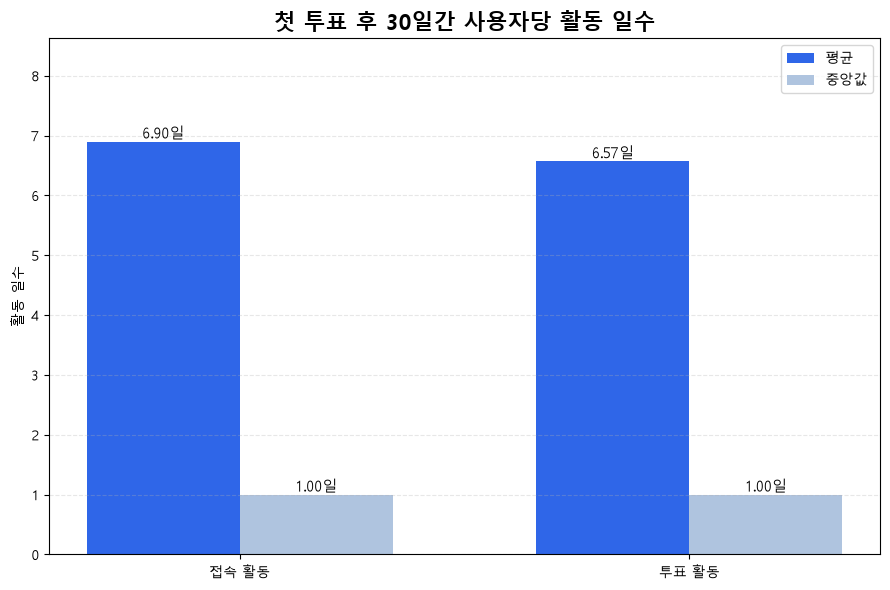

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

labels = activity_summary["activity_type"]
average_days = activity_summary["average_active_days"]
median_days = activity_summary["median_active_days"]

x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 6))

average_bars = ax.bar(
    x - width / 2,
    average_days,
    width,
    label="평균",
    color="#2F66E8"
)

median_bars = ax.bar(
    x + width / 2,
    median_days,
    width,
    label="중앙값",
    color="#AFC4DF"
)

for bar, value in zip(average_bars, average_days):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}일",
        ha="center",
        va="bottom",
        fontsize=11
    )

for bar, value in zip(median_bars, median_days):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}일",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "첫 투표 후 30일간 사용자당 활동 일수",
    fontsize=16,
    fontweight="bold"
)
ax.set_ylabel("활동 일수")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

max_value = max(average_days.max(), median_days.max())
ax.set_ylim(0, max_value * 1.25 if max_value > 0 else 1)

plt.tight_layout()
plt.show()

## 30일 이상 장기 미활동 후 복귀율

첫 투표일을 포함한 활동일(접속일 또는 재투표일)을 사용자별로 다음 활동일까지의 간격을 구한다. 

그 간격이 31일 이상 벌어졌다가 다시 활동한 경우를 '복귀'로, 마지막 활동 후 데이터 종료일까지 30일 이상 흐른 경우까지 포함해 '장기 미활동'으로 잡는다. 접속 기준·투표 기준 두 지표를 따로 집계한다.

In [48]:
# 장기 미접속
long_inactive_return_sql = """
WITH params AS (
  SELECT
    DATE '2026-07-23' AS data_end_date,
    30 AS inactivity_days
),

-- 탈퇴하지 않은 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Acquisition과 Activation 충족 사용자
activated_users AS (
  SELECT
    u.user_id,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 접속 활동일
access_activity_days AS (
  -- 첫 투표일을 최초 앱 활동일로 설정
  SELECT
    '접속 기준' AS metric_type,
    user_id,
    first_vote_date AS activity_date
  FROM activated_users

  UNION DISTINCT

  SELECT
    '접속 기준' AS metric_type,
    a.user_id,
    DATE(s.started_at, 'Asia/Seoul') AS activity_date
  FROM activated_users AS a
  JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = a.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
  WHERE s.started_at IS NOT NULL
    AND DATE(s.started_at, 'Asia/Seoul') > a.first_vote_date
),

-- 투표 활동일
vote_activity_days AS (
  -- 최초 투표일
  SELECT
    '투표 기준' AS metric_type,
    user_id,
    first_vote_date AS activity_date
  FROM activated_users

  UNION DISTINCT

  -- 최초 투표 세션이 아닌 다른 세션의 투표
  SELECT
    '투표 기준' AS metric_type,
    a.user_id,
    DATE(v.voted_at, 'Asia/Seoul') AS activity_date
  FROM activated_users AS a
  JOIN actual_votes AS v
    ON v.user_id = a.user_id
  WHERE v.session_id != a.first_vote_session_id
    AND DATE(v.voted_at, 'Asia/Seoul') > a.first_vote_date
),

all_activity_days AS (
  SELECT * FROM access_activity_days

  UNION ALL

  SELECT * FROM vote_activity_days
),

-- 활동일 다음에 언제 다시 활동했는지 확인
ordered_activity AS (
  SELECT
    metric_type,
    user_id,
    activity_date,

    LEAD(activity_date) OVER (
      PARTITION BY metric_type, user_id
      ORDER BY activity_date
    ) AS next_activity_date

  FROM all_activity_days
),

-- 장기 미활동 및 복귀 여부 판정
episode_flags AS (
  SELECT
    o.metric_type,
    o.user_id,

    -- 장기 미활동 경험 여부
    CASE
      -- 30일 연속 활동하지 않은 후 복귀
      WHEN o.next_activity_date IS NOT NULL
       AND DATE_DIFF(
             o.next_activity_date,
             o.activity_date,
             DAY
           ) >= p.inactivity_days + 1
      THEN 1

      -- 데이터 종료일까지 30일 이상 미활동
      WHEN o.next_activity_date IS NULL
       AND DATE_DIFF(
             p.data_end_date,
             o.activity_date,
             DAY
           ) >= p.inactivity_days
      THEN 1

      ELSE 0
    END AS has_long_inactive_episode,

    -- 장기 미활동 후 실제 복귀 여부
    CASE
      WHEN o.next_activity_date IS NOT NULL
       AND DATE_DIFF(
             o.next_activity_date,
             o.activity_date,
             DAY
           ) >= p.inactivity_days + 1
      THEN 1
      ELSE 0
    END AS has_returned_episode

  FROM ordered_activity AS o
  CROSS JOIN params AS p
),

-- 사용자 단위 집계
user_summary AS (
  SELECT
    metric_type,
    user_id,

    MAX(
      has_long_inactive_episode
    ) AS is_long_inactive_user,

    MAX(
      has_returned_episode
    ) AS is_returned_user

  FROM episode_flags
  GROUP BY
    metric_type,
    user_id
)

SELECT
  metric_type,

  COUNT(*) AS activated_user_count,

  COUNTIF(
    is_long_inactive_user = 1
  ) AS long_inactive_user_count,

  COUNTIF(
    is_returned_user = 1
  ) AS returned_user_count,

  COUNTIF(
    is_long_inactive_user = 1
  )
  -
  COUNTIF(
    is_returned_user = 1
  ) AS not_returned_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(is_returned_user = 1),
      COUNTIF(is_long_inactive_user = 1)
    ) * 100,
    2
  ) AS return_rate_percent

FROM user_summary
GROUP BY metric_type

ORDER BY
  CASE metric_type
    WHEN '접속 기준' THEN 1
    WHEN '투표 기준' THEN 2
  END
"""

In [49]:
cost(long_inactive_return_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [50]:
df_long_return = bq.query(
    long_inactive_return_sql
).to_dataframe()

display(df_long_return)

,metric_type,activated_user_count,long_inactive_user_count,returned_user_count,not_returned_user_count,return_rate_percent
0,접속 기준,14889,13320,655,12665,4.92
1,투표 기준,14889,13322,656,12666,4.92


In [51]:
metric_order = ["접속 기준", "투표 기준"]

formatted_long_return = (
    df_long_return
    .set_index("metric_type")
    .reindex(metric_order)
    .reset_index()
)

for _, row in formatted_long_return.iterrows():
    print(f"[{row['metric_type']}]")

    print(
        f"장기 미활동 사용자: "
        f"{int(row['long_inactive_user_count']):,}명"
    )

    print(
        f"복귀 사용자: "
        f"{int(row['returned_user_count']):,}명"
    )

    print(
        f"미복귀 사용자: "
        f"{int(row['not_returned_user_count']):,}명"
    )

    print(
        f"복귀율: "
        f"{float(row['return_rate_percent']):.2f}%"
    )

    print()

[접속 기준]
장기 미활동 사용자: 13,320명
복귀 사용자: 655명
미복귀 사용자: 12,665명
복귀율: 4.92%

[투표 기준]
장기 미활동 사용자: 13,322명
복귀 사용자: 656명
미복귀 사용자: 12,666명
복귀율: 4.92%



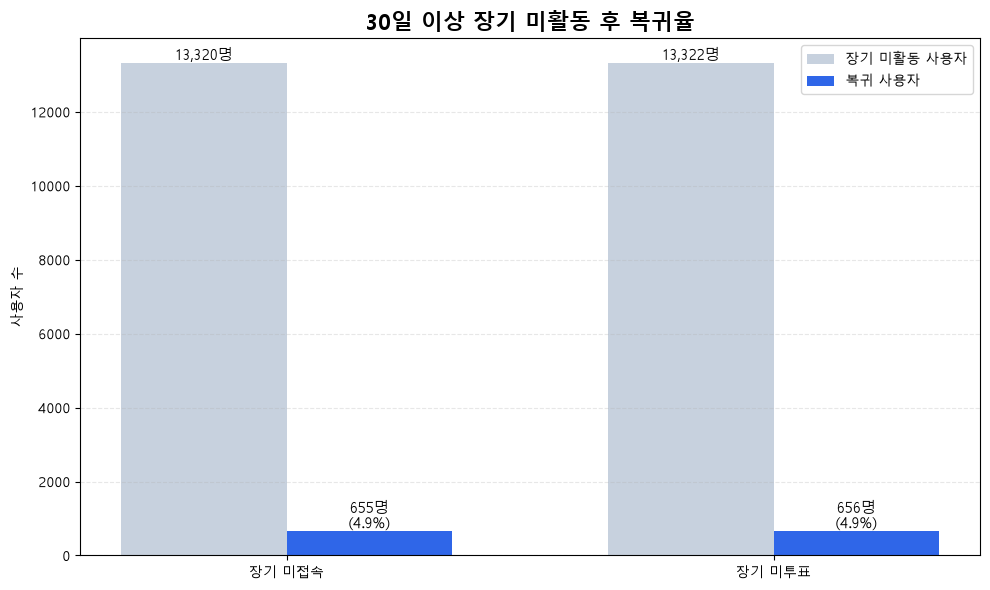

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

labels = df_long_return["metric_type"].replace({
    "접속 기준": "장기 미접속",
    "투표 기준": "장기 미투표"
})

inactive_counts = df_long_return["long_inactive_user_count"]
returned_counts = df_long_return["returned_user_count"]
return_rates = df_long_return["return_rate_percent"]

x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 6))

inactive_bars = ax.bar(
    x - width / 2,
    inactive_counts,
    width,
    label="장기 미활동 사용자",
    color="#C7D1DE"
)

returned_bars = ax.bar(
    x + width / 2,
    returned_counts,
    width,
    label="복귀 사용자",
    color="#2F66E8"
)

for bar, value in zip(inactive_bars, inactive_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}명",
        ha="center",
        va="bottom",
        fontsize=11
    )

for bar, value, rate in zip(
    returned_bars,
    returned_counts,
    return_rates
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}명\n({rate:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "30일 이상 장기 미활동 후 복귀율",
    fontsize=16,
    fontweight="bold"
)
ax.set_ylabel("사용자 수")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

쿼리에서 변환되지 않은 학교 유형 값과 시각화에서 지정한 중학교·고등학교가 서로 맞지 않아, reindex() 과정에서 값이 전부 결측치가 된 것

## 학교 유형별 리텐션 — 결측치 원인 확인과 재계산

`school_type` 원본 값이 그래프에서 기대한 '중학교'·'고등학교' 표기와 어긋나 있었다. 

이어지는 셀은 그 값을 확인하고, `school_type`이 `'M'`/`'MIDDLE'`류·`'H'`/`'HIGH'`류인 경우를 각각 '중학교'·'고등학교'로 정규화하는 CASE 문으로 쿼리를 

다시 작성해 D1·D7·D30 리텐션을 집계한 뒤, 정규화된 이름으로 학교 유형별 막대그래프를 다시 그린다.

In [ ]:
# 1. 실제 학교 유형 값 확인
display(df_school_type_retention)

print(
    df_school_type_retention["school_type_name"]
    .drop_duplicates()
    .tolist()
)

,school_type_name,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,HIGH,D1,8487,3903,45.99,3656,43.08
1,MIDDLE,D1,6356,2822,44.40,2637,41.49
2,HIGH,D7,8392,4939,58.85,4801,57.21
3,MIDDLE,D7,6269,3603,57.47,3507,55.94
4,HIGH,D30,8017,4821,60.13,4698,58.60
5,MIDDLE,D30,5993,3508,58.53,3422,57.10


['HIGH', 'MIDDLE']


In [90]:
# 2. 수정된 학교 유형별 쿼리
school_type_retention_sql = retention_common_ctes + """
SELECT
  CASE
    WHEN school_type = 'M'
      OR UPPER(school_type) LIKE '%MIDDLE%'
    THEN '중학교'

    WHEN school_type = 'H'
      OR UPPER(school_type) LIKE '%HIGH%'
    THEN '고등학교'

    ELSE school_type
  END AS school_type_name,

  retention_period,

  COUNT(*) AS eligible_user_count,

  COUNTIF(
    login_retained = 1
  ) AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  COUNTIF(
    vote_retained = 1
  ) AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM retention_user_flags

GROUP BY
  school_type,
  retention_period,
  sort_order

ORDER BY
  sort_order,
  school_type_name
"""

In [91]:
cost(school_type_retention_sql)

예상 스캔량: 416.145 MiB
예상 스캔량: 0.406392 GiB
월 1 TiB 무료 용량의 약 0.03968669%


0.40639173332601786

In [92]:
df_school_type_retention = bq.query(
    school_type_retention_sql
).to_dataframe()

display(df_school_type_retention)

,school_type_name,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,고등학교,D1,8487,3903,45.99,3656,43.08
1,중학교,D1,6356,2822,44.40,2637,41.49
2,고등학교,D7,8392,4939,58.85,4801,57.21
3,중학교,D7,6269,3603,57.47,3507,55.94
4,고등학교,D30,8017,4821,60.13,4698,58.60
5,중학교,D30,5993,3508,58.53,3422,57.10


[접속 리텐션 시각화 데이터]


retention_period,D1,D7,D30
school_type_name,,,
중학교,44.40,57.47,58.53
고등학교,45.99,58.85,60.13


[투표 리텐션 시각화 데이터]


retention_period,D1,D7,D30
school_type_name,,,
중학교,41.49,55.94,57.1
고등학교,43.08,57.21,58.6


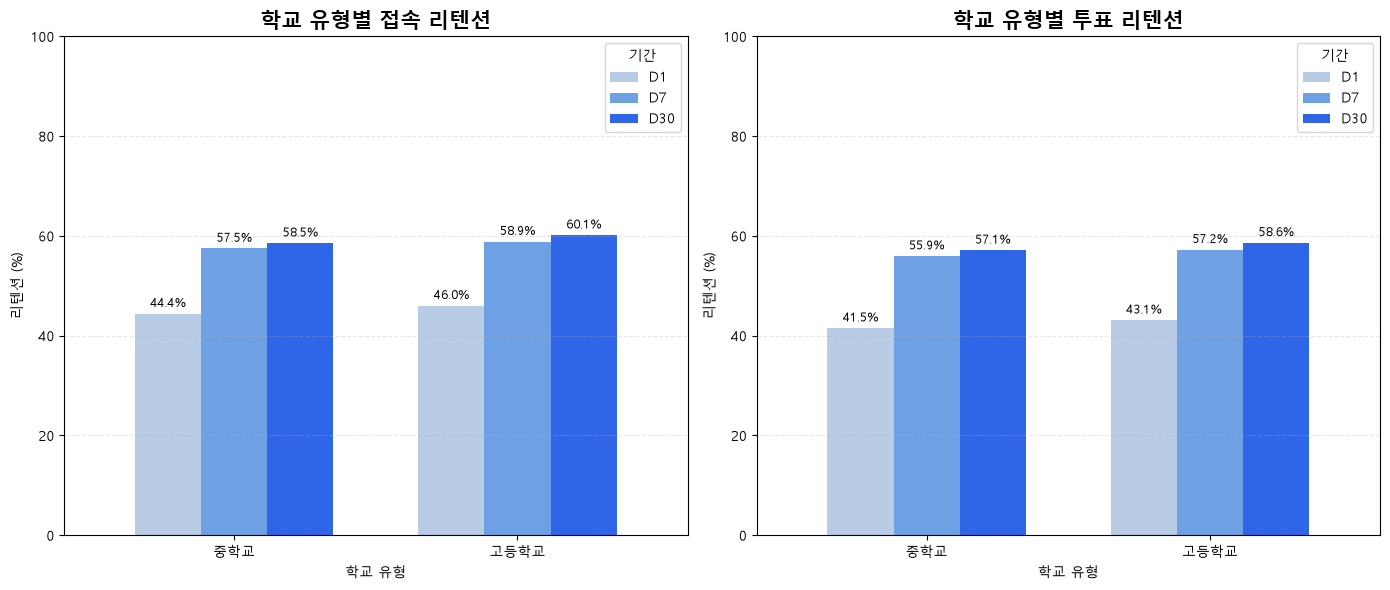

In [93]:
# 3. 수정한 시각화
import pandas as pd
import matplotlib.pyplot as plt
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

plot_df = df_school_type_retention.copy()

# 리텐션 컬럼을 확실하게 숫자형으로 변환
rate_columns = [
    "login_retention_rate_percent",
    "vote_retention_rate_percent"
]

for column in rate_columns:
    plot_df[column] = pd.to_numeric(
        plot_df[column],
        errors="coerce"
    )

period_order = ["D1", "D7", "D30"]
school_type_order = ["중학교", "고등학교"]

login_pivot = (
    plot_df
    .pivot(
        index="school_type_name",
        columns="retention_period",
        values="login_retention_rate_percent"
    )
    .reindex(
        index=school_type_order,
        columns=period_order
    )
)

vote_pivot = (
    plot_df
    .pivot(
        index="school_type_name",
        columns="retention_period",
        values="vote_retention_rate_percent"
    )
    .reindex(
        index=school_type_order,
        columns=period_order
    )
)

print("[접속 리텐션 시각화 데이터]")
display(login_pivot)

print("[투표 리텐션 시각화 데이터]")
display(vote_pivot)

# 데이터가 모두 비어 있으면 그래프를 그리지 않고 오류 표시
if login_pivot.isna().all().all():
    raise ValueError(
        "접속 리텐션 데이터가 모두 비어 있습니다. "
        "school_type_name 값을 확인해주세요."
    )

if vote_pivot.isna().all().all():
    raise ValueError(
        "투표 리텐션 데이터가 모두 비어 있습니다. "
        "school_type_name 값을 확인해주세요."
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

login_pivot.plot(
    kind="bar",
    ax=axes[0],
    color=["#B9CCE5", "#6EA1E4", "#2F66E8"],
    width=0.7
)

vote_pivot.plot(
    kind="bar",
    ax=axes[1],
    color=["#B9CCE5", "#6EA1E4", "#2F66E8"],
    width=0.7
)

for ax, title in zip(
    axes,
    [
        "학교 유형별 접속 리텐션",
        "학교 유형별 투표 리텐션"
    ]
):
    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold"
    )
    ax.set_xlabel("학교 유형")
    ax.set_ylabel("리텐션 (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(title="기간")

    for container in ax.containers:
        labels = [
            f"{bar.get_height():.1f}%"
            if pd.notna(bar.get_height())
            else ""
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()

## 학교 유형·학년별 리텐션

`grade_class`·`school`을 조인해 사용자별 학교 유형과 학년을 붙이고, 친구 5명을 확보했고 학교 유형이 중·고등학교이며 학년이 1~3인 사용자만 대상으로 

D1·D7·D30 접속·투표 리텐션을 학교 유형×학년 조합별로 집계해 그래프로 그린다.

In [2]:
# 학년별
school_grade_retention_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

retention_windows AS (
  SELECT
    'D1' AS retention_period,
    1 AS start_day,
    1 AS end_day,
    1 AS sort_order

  UNION ALL

  SELECT
    'D7',
    1,
    7,
    2

  UNION ALL

  SELECT
    'D30',
    1,
    30,
    3
),

-- 1. 탈퇴하지 않은 합성 데이터 사용자와 학교·학년 정보
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at,

    CASE
      WHEN UPPER(CAST(s.school_type AS STRING))
        IN ('M', 'MIDDLE', 'MIDDLE_SCHOOL')
      THEN '중학교'

      WHEN UPPER(CAST(s.school_type AS STRING))
        IN ('H', 'HIGH', 'HIGH_SCHOOL')
      THEN '고등학교'

      ELSE CAST(s.school_type AS STRING)
    END AS school_type_name,

    gc.grade

  FROM `ping-v2-503916.raw.app_user` AS u

  JOIN `ping-v2-503916.raw.grade_class` AS gc
    ON gc._source = u._source
   AND gc.id = u.class_id
   AND gc._deleted_at IS NULL

  JOIN `ping-v2-503916.raw.school` AS s
    ON s._source = gc._source
   AND s.id = gc.school_id
   AND s._deleted_at IS NULL

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

-- 2. 실제로 완료한 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at

  FROM `ping-v2-503916.raw.vote_item` AS vi

  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 3. 사용자별 최초 실제 투표 시점과 해당 세션
first_vote AS (
  SELECT
    user_id,

    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY
        voted_at,
        session_id
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes

  GROUP BY user_id
),

-- 4. Acquisition과 Activation을 모두 충족한 사용자
activated_users AS (
  SELECT
    u.user_id,
    u.school_type_name,
    u.grade,

    DATE(
      f.first_vote_at,
      'Asia/Seoul'
    ) AS first_vote_date,

    f.first_vote_session_id

  FROM valid_users AS u

  JOIN first_vote AS f
    ON f.user_id = u.user_id

  -- 친구 5명 확보 조건
  WHERE u.service_unlocked_at IS NOT NULL
    AND u.school_type_name IN ('중학교', '고등학교')
    AND u.grade IN (1, 2, 3)
),

-- 5. 첫 투표 이후 다시 접속한 날짜
login_return_days AS (
  SELECT DISTINCT
    a.user_id,

    DATE(
      us.started_at,
      'Asia/Seoul'
    ) AS activity_date

  FROM activated_users AS a

  JOIN `ping-v2-503916.raw.user_session` AS us
    ON us._source = 'local'
   AND us.user_id = a.user_id
   AND us._deleted_at IS NULL

  WHERE us.started_at IS NOT NULL

    -- 첫 투표 당일 제외
    AND DATE(
          us.started_at,
          'Asia/Seoul'
        ) > a.first_vote_date
),

-- 6. 최초 투표 세션이 아닌 다른 세션에서 재투표한 날짜
vote_return_days AS (
  SELECT DISTINCT
    a.user_id,

    DATE(
      v.voted_at,
      'Asia/Seoul'
    ) AS activity_date

  FROM activated_users AS a

  JOIN actual_votes AS v
    ON v.user_id = a.user_id

  WHERE v.session_id != a.first_vote_session_id

    -- 첫 투표 당일 제외
    AND DATE(
          v.voted_at,
          'Asia/Seoul'
        ) > a.first_vote_date
),

-- 7. 기간을 끝까지 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    a.user_id,
    a.school_type_name,
    a.grade,
    a.first_vote_date,

    w.retention_period,
    w.start_day,
    w.end_day,
    w.sort_order

  FROM activated_users AS a

  CROSS JOIN retention_windows AS w
  CROSS JOIN params AS p

  WHERE a.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL w.end_day DAY
       )
),

-- 8. 사용자별 접속 리텐션 여부
login_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN l.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS login_retained

  FROM eligible_users AS e

  LEFT JOIN login_return_days AS l
    ON l.user_id = e.user_id

   AND DATE_DIFF(
         l.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
),

-- 9. 사용자별 투표 리텐션 여부
-- 힌트 구매는 포함하지 않음
vote_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN v.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS vote_retained

  FROM eligible_users AS e

  LEFT JOIN vote_return_days AS v
    ON v.user_id = e.user_id

   AND DATE_DIFF(
         v.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
)

-- 10. 학교 유형·학년·기간별 집계
SELECT
  e.school_type_name,
  e.grade,
  e.retention_period,

  COUNT(*) AS eligible_user_count,

  COUNTIF(
    l.login_retained = 1
  ) AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(l.login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  COUNTIF(
    v.vote_retained = 1
  ) AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM eligible_users AS e

JOIN login_flags AS l
  ON l.user_id = e.user_id
 AND l.retention_period = e.retention_period

JOIN vote_flags AS v
  ON v.user_id = e.user_id
 AND v.retention_period = e.retention_period

GROUP BY
  e.school_type_name,
  e.grade,
  e.retention_period,
  e.sort_order

ORDER BY
  e.sort_order,

  CASE e.school_type_name
    WHEN '중학교' THEN 1
    WHEN '고등학교' THEN 2
    ELSE 3
  END,

  e.grade
"""

In [3]:
cost(school_grade_retention_sql)

예상 스캔량: 416.156 MiB
예상 스캔량: 0.406402 GiB
월 1 TiB 무료 용량의 약 0.03968769%


0.40640195552259684

In [4]:
df_school_grade_retention = bq.query(
    school_grade_retention_sql
).to_dataframe()

display(df_school_grade_retention)

,school_type_name,grade,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,중학교,1,D1,2118,940,44.38,884,41.74
1,중학교,2,D1,2094,912,43.55,845,40.35
2,중학교,3,D1,2144,970,45.24,908,42.35
3,고등학교,1,D1,2854,1281,44.88,1210,42.40
4,고등학교,2,D1,2835,1320,46.56,1237,43.63
5,고등학교,3,D1,2798,1302,46.53,1209,43.21
6,중학교,1,D7,2098,1192,56.82,1165,55.53
7,중학교,2,D7,2061,1174,56.96,1138,55.22
8,중학교,3,D7,2110,1237,58.63,1204,57.06
9,고등학교,1,D7,2826,1642,58.10,1601,56.65


In [5]:
import pandas as pd

result_df = df_school_grade_retention.copy()

# BigQuery 숫자 자료형을 출력하기 편하게 변환
numeric_columns = [
    "grade",
    "eligible_user_count",
    "login_retained_user_count",
    "login_retention_rate_percent",
    "vote_retained_user_count",
    "vote_retention_rate_percent"
]

for column in numeric_columns:
    result_df[column] = pd.to_numeric(
        result_df[column],
        errors="coerce"
    )

school_type_order = [
    "중학교",
    "고등학교"
]

period_order = [
    "D1",
    "D7",
    "D30"
]

result_df["school_type_order"] = (
    result_df["school_type_name"]
    .map({
        "중학교": 1,
        "고등학교": 2
    })
)

result_df["period_order"] = (
    result_df["retention_period"]
    .map({
        "D1": 1,
        "D7": 2,
        "D30": 3
    })
)

result_df = result_df.sort_values(
    [
        "school_type_order",
        "grade",
        "period_order"
    ]
)

for school_type in school_type_order:
    print(f"[{school_type}]")
    print()

    type_df = result_df[
        result_df["school_type_name"] == school_type
    ]

    for grade in [1, 2, 3]:
        print(f"{grade}학년")

        grade_df = type_df[
            type_df["grade"] == grade
        ]

        for _, row in grade_df.iterrows():
            print(
                f"- {row['retention_period']} "
                f"관찰 가능 사용자: "
                f"{int(row['eligible_user_count']):,}명"
            )

            print(
                f"  접속 리텐션: "
                f"{int(row['login_retained_user_count']):,}명 "
                f"({float(row['login_retention_rate_percent']):.2f}%)"
            )

            print(
                f"  투표 리텐션: "
                f"{int(row['vote_retained_user_count']):,}명 "
                f"({float(row['vote_retention_rate_percent']):.2f}%)"
            )

        print()

    print()

[중학교]

1학년
- D1 관찰 가능 사용자: 2,118명
  접속 리텐션: 940명 (44.38%)
  투표 리텐션: 884명 (41.74%)
- D7 관찰 가능 사용자: 2,098명
  접속 리텐션: 1,192명 (56.82%)
  투표 리텐션: 1,165명 (55.53%)
- D30 관찰 가능 사용자: 2,016명
  접속 리텐션: 1,164명 (57.74%)
  투표 리텐션: 1,139명 (56.50%)

2학년
- D1 관찰 가능 사용자: 2,094명
  접속 리텐션: 912명 (43.55%)
  투표 리텐션: 845명 (40.35%)
- D7 관찰 가능 사용자: 2,061명
  접속 리텐션: 1,174명 (56.96%)
  투표 리텐션: 1,138명 (55.22%)
- D30 관찰 가능 사용자: 1,970명
  접속 리텐션: 1,140명 (57.87%)
  투표 리텐션: 1,107명 (56.19%)

3학년
- D1 관찰 가능 사용자: 2,144명
  접속 리텐션: 970명 (45.24%)
  투표 리텐션: 908명 (42.35%)
- D7 관찰 가능 사용자: 2,110명
  접속 리텐션: 1,237명 (58.63%)
  투표 리텐션: 1,204명 (57.06%)
- D30 관찰 가능 사용자: 2,007명
  접속 리텐션: 1,204명 (59.99%)
  투표 리텐션: 1,176명 (58.59%)


[고등학교]

1학년
- D1 관찰 가능 사용자: 2,854명
  접속 리텐션: 1,281명 (44.88%)
  투표 리텐션: 1,210명 (42.40%)
- D7 관찰 가능 사용자: 2,826명
  접속 리텐션: 1,642명 (58.10%)
  투표 리텐션: 1,601명 (56.65%)
- D30 관찰 가능 사용자: 2,698명
  접속 리텐션: 1,596명 (59.15%)
  투표 리텐션: 1,560명 (57.82%)

2학년
- D1 관찰 가능 사용자: 2,835명
  접속 리텐션: 1,320명 (46.56%)
  투표 리텐션: 1,237명 (4

[접속 리텐션 시각화 데이터]


retention_period,D1,D7,D30
school_grade,,,
중학교 1학년,44.38,56.82,57.74
중학교 2학년,43.55,56.96,57.87
중학교 3학년,45.24,58.63,59.99
고등학교 1학년,44.88,58.10,59.15
고등학교 2학년,46.56,59.79,61.22
고등학교 3학년,46.53,58.67,60.04


[투표 리텐션 시각화 데이터]


retention_period,D1,D7,D30
school_grade,,,
중학교 1학년,41.74,55.53,56.50
중학교 2학년,40.35,55.22,56.19
중학교 3학년,42.35,57.06,58.59
고등학교 1학년,42.40,56.65,57.82
고등학교 2학년,43.63,58.18,59.76
고등학교 3학년,43.21,56.79,58.23


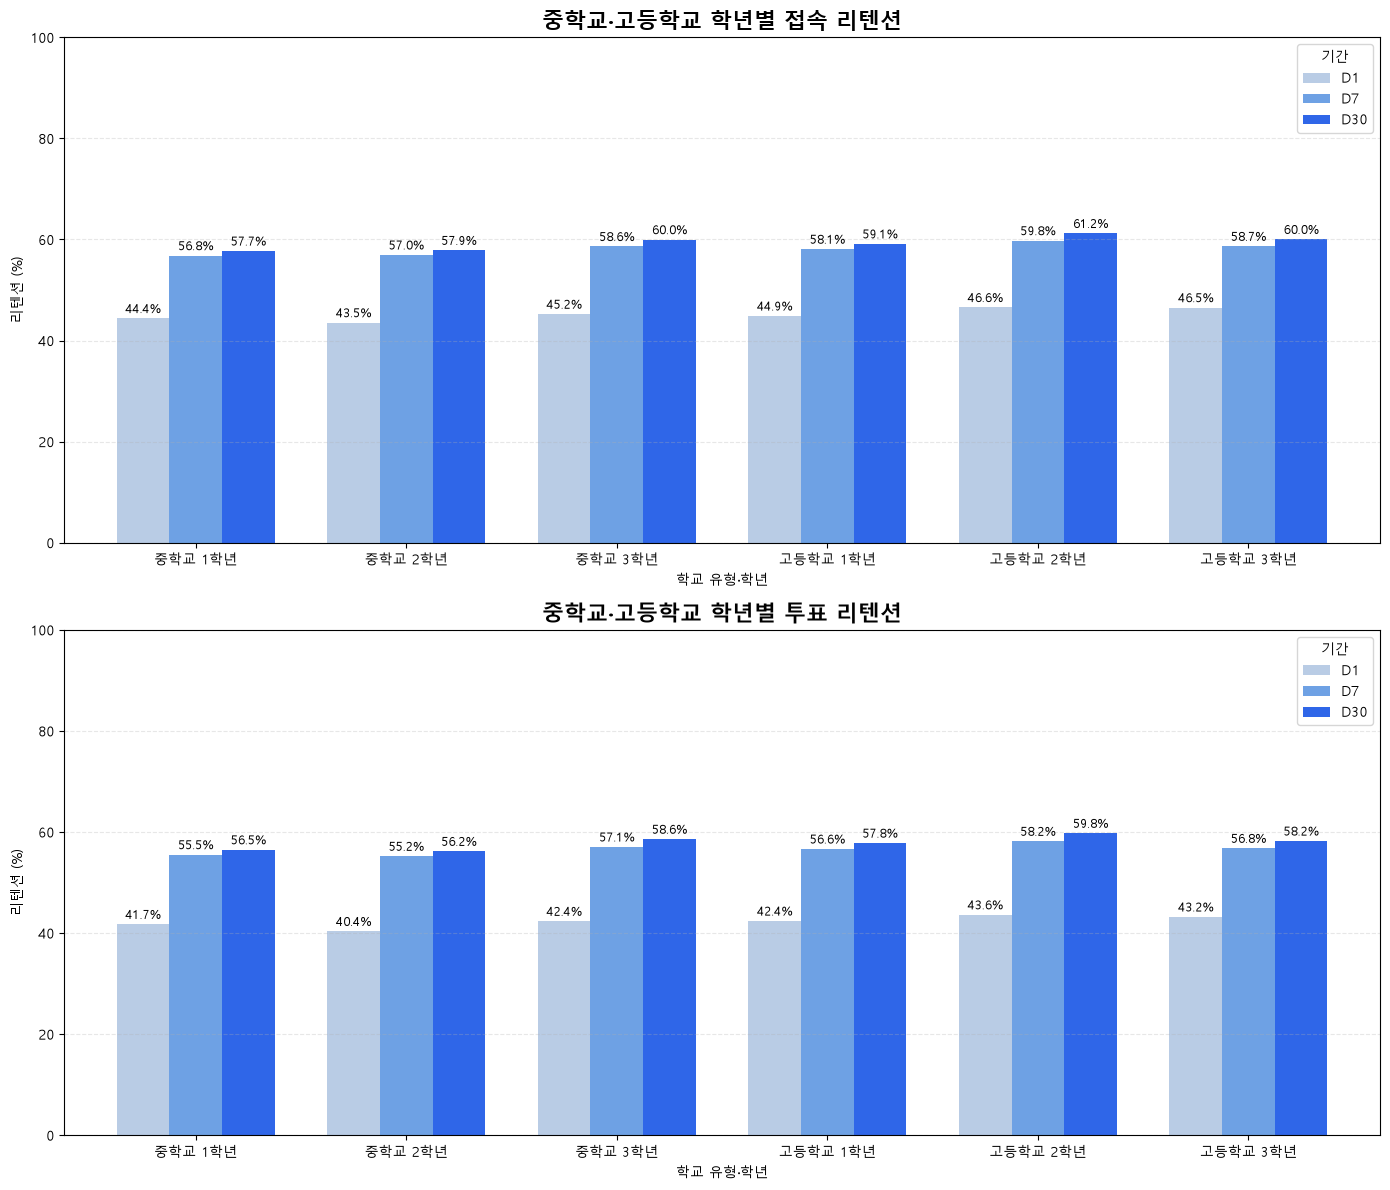

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import platform

# Windows·Mac 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

plot_df = df_school_grade_retention.copy()

# 숫자형 변환
plot_df["grade"] = pd.to_numeric(
    plot_df["grade"],
    errors="coerce"
)

rate_columns = [
    "login_retention_rate_percent",
    "vote_retention_rate_percent"
]

for column in rate_columns:
    plot_df[column] = pd.to_numeric(
        plot_df[column],
        errors="coerce"
    )

# 그래프에 사용할 학교 유형·학년 표시명
plot_df["school_grade"] = (
    plot_df["school_type_name"]
    + " "
    + plot_df["grade"].astype("Int64").astype(str)
    + "학년"
)

school_grade_order = [
    "중학교 1학년",
    "중학교 2학년",
    "중학교 3학년",
    "고등학교 1학년",
    "고등학교 2학년",
    "고등학교 3학년"
]

period_order = [
    "D1",
    "D7",
    "D30"
]

# 접속 리텐션 피벗
login_pivot = (
    plot_df
    .pivot(
        index="school_grade",
        columns="retention_period",
        values="login_retention_rate_percent"
    )
    .reindex(
        index=school_grade_order,
        columns=period_order
    )
)

# 투표 리텐션 피벗
vote_pivot = (
    plot_df
    .pivot(
        index="school_grade",
        columns="retention_period",
        values="vote_retention_rate_percent"
    )
    .reindex(
        index=school_grade_order,
        columns=period_order
    )
)

# 그래프를 그리기 전에 실제 피벗 데이터 확인
print("[접속 리텐션 시각화 데이터]")
display(login_pivot)

print("[투표 리텐션 시각화 데이터]")
display(vote_pivot)

if login_pivot.isna().all().all():
    raise ValueError(
        "접속 리텐션 데이터가 모두 비어 있습니다. "
        "학교 유형과 학년 값을 확인해주세요."
    )

if vote_pivot.isna().all().all():
    raise ValueError(
        "투표 리텐션 데이터가 모두 비어 있습니다. "
        "학교 유형과 학년 값을 확인해주세요."
    )

colors = [
    "#B9CCE5",
    "#6EA1E4",
    "#2F66E8"
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 12)
)

# 접속 리텐션
login_pivot.plot(
    kind="bar",
    ax=axes[0],
    color=colors,
    width=0.75
)

# 투표 리텐션
vote_pivot.plot(
    kind="bar",
    ax=axes[1],
    color=colors,
    width=0.75
)

titles = [
    "중학교·고등학교 학년별 접속 리텐션",
    "중학교·고등학교 학년별 투표 리텐션"
]

for ax, title in zip(axes, titles):
    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold"
    )

    ax.set_xlabel("학교 유형·학년")
    ax.set_ylabel("리텐션 (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(
        axis="x",
        rotation=0
    )
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )
    ax.legend(
        title="기간"
    )

    # 막대 위 퍼센트 표시
    for container in ax.containers:
        labels = []

        for bar in container:
            height = bar.get_height()

            if pd.notna(height):
                labels.append(
                    f"{height:.1f}%"
                )
            else:
                labels.append("")

        ax.bar_label(
            container,
            labels=labels,
            padding=2,
            fontsize=9
        )

plt.tight_layout()
plt.show()

## 주차별 레인지 리텐션 (W1~W4)

첫 투표 이후를 1~7일(W1)·8~14일(W2)·15~21일(W3)·22~28일(W4)로 서로 겹치지 않게 나눠, 각 구간 안에 재접속·재투표가 있었는지를 구간별 리텐션율로 계산하고 꺾은선 그래프로 그린다.

In [7]:
# 레인지 리텐션
weekly_range_retention_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

-- 서로 겹치지 않는 주차별 레인지
retention_windows AS (
  SELECT
    'W1' AS retention_period,
    1 AS start_day,
    7 AS end_day,
    1 AS sort_order

  UNION ALL

  SELECT
    'W2',
    8,
    14,
    2

  UNION ALL

  SELECT
    'W3',
    15,
    21,
    3

  UNION ALL

  SELECT
    'W4',
    22,
    28,
    4
),

-- 탈퇴하지 않은 합성 데이터 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 유효한 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1

      FROM `ping-v2-503916.raw.user_withdrawal` AS w

      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

-- 실제 투표를 완료한 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at

  FROM `ping-v2-503916.raw.vote_item` AS vi

  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표 시점과 해당 투표 세션
first_vote AS (
  SELECT
    user_id,

    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY
        voted_at,
        session_id
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes

  GROUP BY user_id
),

-- Acquisition과 Activation을 모두 충족한 사용자
activated_users AS (
  SELECT
    u.user_id,

    DATE(
      f.first_vote_at,
      'Asia/Seoul'
    ) AS first_vote_date,

    f.first_vote_session_id

  FROM valid_users AS u

  JOIN first_vote AS f
    ON f.user_id = u.user_id

  -- 친구 5명 확보
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 첫 투표 이후 다시 접속한 날짜
login_return_days AS (
  SELECT DISTINCT
    a.user_id,

    DATE(
      us.started_at,
      'Asia/Seoul'
    ) AS activity_date

  FROM activated_users AS a

  JOIN `ping-v2-503916.raw.user_session` AS us
    ON us._source = 'local'
   AND us.user_id = a.user_id
   AND us._deleted_at IS NULL

  WHERE us.started_at IS NOT NULL

    -- 첫 투표 당일 제외
    AND DATE(
          us.started_at,
          'Asia/Seoul'
        ) > a.first_vote_date
),

-- 첫 투표와 다른 세션에서 다시 투표한 날짜
vote_return_days AS (
  SELECT DISTINCT
    a.user_id,

    DATE(
      v.voted_at,
      'Asia/Seoul'
    ) AS activity_date

  FROM activated_users AS a

  JOIN actual_votes AS v
    ON v.user_id = a.user_id

  -- 최초 투표 세션의 나머지 투표는 재투표에서 제외
  WHERE v.session_id != a.first_vote_session_id

    -- 첫 투표 당일 제외
    AND DATE(
          v.voted_at,
          'Asia/Seoul'
        ) > a.first_vote_date
),

-- 각 주차를 끝까지 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    a.user_id,
    a.first_vote_date,

    w.retention_period,
    w.start_day,
    w.end_day,
    w.sort_order

  FROM activated_users AS a

  CROSS JOIN retention_windows AS w
  CROSS JOIN params AS p

  WHERE a.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL w.end_day DAY
       )
),

-- 사용자별 주차 접속 리텐션 여부
login_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN l.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS login_retained

  FROM eligible_users AS e

  LEFT JOIN login_return_days AS l
    ON l.user_id = e.user_id

   AND DATE_DIFF(
         l.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
),

-- 사용자별 주차 투표 리텐션 여부
-- 힌트 구매는 포함하지 않음
vote_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN v.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS vote_retained

  FROM eligible_users AS e

  LEFT JOIN vote_return_days AS v
    ON v.user_id = e.user_id

   AND DATE_DIFF(
         v.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
)

SELECT
  e.retention_period,
  e.start_day,
  e.end_day,

  COUNT(*) AS eligible_user_count,

  COUNTIF(
    l.login_retained = 1
  ) AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(l.login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  COUNTIF(
    v.vote_retained = 1
  ) AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM eligible_users AS e

JOIN login_flags AS l
  ON l.user_id = e.user_id
 AND l.retention_period = e.retention_period

JOIN vote_flags AS v
  ON v.user_id = e.user_id
 AND v.retention_period = e.retention_period

GROUP BY
  e.retention_period,
  e.start_day,
  e.end_day,
  e.sort_order

ORDER BY e.sort_order
"""

In [8]:
cost(weekly_range_retention_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [9]:
df_weekly_range_retention = bq.query(
    weekly_range_retention_sql
).to_dataframe()

display(df_weekly_range_retention)

,retention_period,start_day,end_day,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,W1,1,7,14661,8542,58.26,8308,56.67
1,W2,8,14,14453,5195,35.94,5153,35.65
2,W3,15,21,14250,4062,28.51,4033,28.30
3,W4,22,28,14057,3011,21.42,2980,21.20


In [10]:
import pandas as pd

weekly_output = df_weekly_range_retention.copy()

numeric_columns = [
    "start_day",
    "end_day",
    "eligible_user_count",
    "login_retained_user_count",
    "login_retention_rate_percent",
    "vote_retained_user_count",
    "vote_retention_rate_percent"
]

for column in numeric_columns:
    weekly_output[column] = pd.to_numeric(
        weekly_output[column],
        errors="coerce"
    )

period_order = {
    "W1": 1,
    "W2": 2,
    "W3": 3,
    "W4": 4
}

weekly_output["period_order"] = (
    weekly_output["retention_period"]
    .map(period_order)
)

weekly_output = weekly_output.sort_values(
    "period_order"
)

for _, row in weekly_output.iterrows():
    print(
        f"[{row['retention_period']}: "
        f"{int(row['start_day'])}~"
        f"{int(row['end_day'])}일]"
    )

    print(
        f"관찰 가능 사용자: "
        f"{int(row['eligible_user_count']):,}명"
    )

    print(
        f"접속 리텐션: "
        f"{int(row['login_retained_user_count']):,}명 "
        f"({float(row['login_retention_rate_percent']):.2f}%)"
    )

    print(
        f"투표 리텐션: "
        f"{int(row['vote_retained_user_count']):,}명 "
        f"({float(row['vote_retention_rate_percent']):.2f}%)"
    )

    print()

[W1: 1~7일]
관찰 가능 사용자: 14,661명
접속 리텐션: 8,542명 (58.26%)
투표 리텐션: 8,308명 (56.67%)

[W2: 8~14일]
관찰 가능 사용자: 14,453명
접속 리텐션: 5,195명 (35.94%)
투표 리텐션: 5,153명 (35.65%)

[W3: 15~21일]
관찰 가능 사용자: 14,250명
접속 리텐션: 4,062명 (28.51%)
투표 리텐션: 4,033명 (28.30%)

[W4: 22~28일]
관찰 가능 사용자: 14,057명
접속 리텐션: 3,011명 (21.42%)
투표 리텐션: 2,980명 (21.20%)



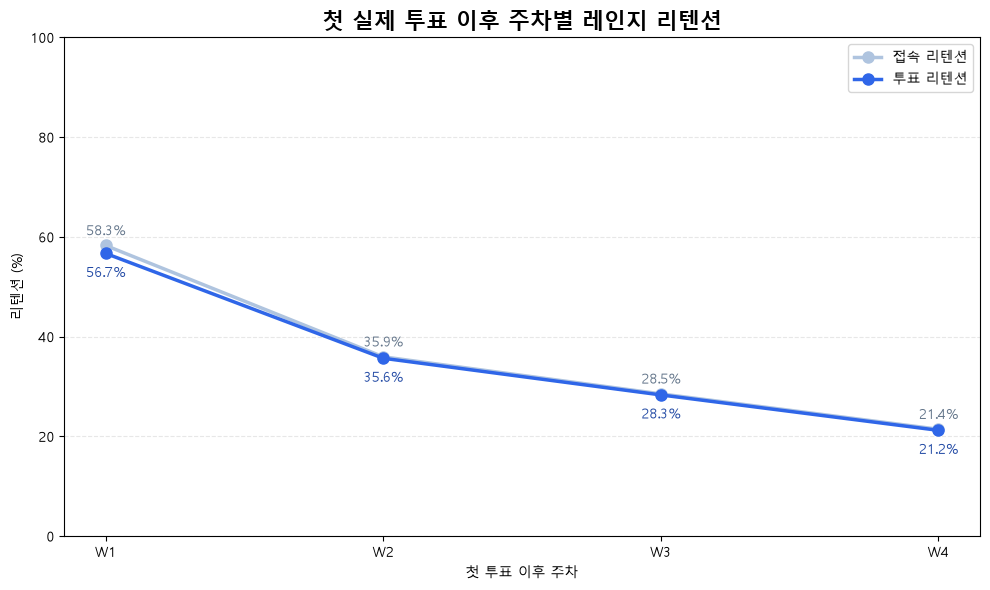

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

plot_df = df_weekly_range_retention.copy()

rate_columns = [
    "login_retention_rate_percent",
    "vote_retention_rate_percent"
]

for column in rate_columns:
    plot_df[column] = pd.to_numeric(
        plot_df[column],
        errors="coerce"
    )

period_order = [
    "W1",
    "W2",
    "W3",
    "W4"
]

plot_df["period_order"] = (
    plot_df["retention_period"]
    .map({
        "W1": 1,
        "W2": 2,
        "W3": 3,
        "W4": 4
    })
)

plot_df = plot_df.sort_values(
    "period_order"
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

# 접속 리텐션
ax.plot(
    plot_df["retention_period"],
    plot_df["login_retention_rate_percent"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#AFC4DF",
    label="접속 리텐션"
)

# 투표 리텐션
ax.plot(
    plot_df["retention_period"],
    plot_df["vote_retention_rate_percent"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#2F66E8",
    label="투표 리텐션"
)

# 데이터 레이블
for _, row in plot_df.iterrows():
    ax.text(
        row["retention_period"],
        row["login_retention_rate_percent"] + 1.5,
        f"{row['login_retention_rate_percent']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#63758A"
    )

    ax.text(
        row["retention_period"],
        row["vote_retention_rate_percent"] - 2.5,
        f"{row['vote_retention_rate_percent']:.1f}%",
        ha="center",
        va="top",
        fontsize=10,
        color="#2149A4"
    )

ax.set_title(
    "첫 실제 투표 이후 주차별 레인지 리텐션",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("첫 투표 이후 주차")
ax.set_ylabel("리텐션 (%)")
ax.set_ylim(0, 100)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

## 출시 직후 vs 개학 직후 주별 코호트

최초 실제 투표일이 출시 직후 또는 개학 직후에 속하는 사용자를 

각각 월요일 시작 주 단위 코호트로 묶고, W0(기준 주)부터 W8까지 구간별 재투표 리텐션을 계산해 코호트별 히트맵으로 그린다.

In [12]:
# 주 단위 코호트
seasonal_vote_cohort_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

-- 코호트 이후 서로 겹치지 않는 주차 구간
retention_windows AS (
  SELECT 'W0' AS retention_period, 0 AS start_day, 0 AS end_day, 0 AS sort_order
  UNION ALL
  SELECT 'W1', 1, 7, 1
  UNION ALL
  SELECT 'W2', 8, 14, 2
  UNION ALL
  SELECT 'W3', 15, 21, 3
  UNION ALL
  SELECT 'W4', 22, 28, 4
  UNION ALL
  SELECT 'W5', 29, 35, 5
  UNION ALL
  SELECT 'W6', 36, 42, 6
  UNION ALL
  SELECT 'W7', 43, 49, 7
  UNION ALL
  SELECT 'W8', 50, 56, 8
),

-- 탈퇴하지 않은 합성 데이터 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at

  FROM `ping-v2-503916.raw.app_user` AS u

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 유효한 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1

      FROM `ping-v2-503916.raw.user_withdrawal` AS w

      WHERE w._source = u._source
        AND w.user_id = u.id
        AND w._deleted_at IS NULL
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at

  FROM `ping-v2-503916.raw.vote_item` AS vi

  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표 시점과 최초 투표 세션
first_vote AS (
  SELECT
    user_id,

    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY
        voted_at,
        session_id
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes

  GROUP BY user_id
),

-- Acquisition과 Activation을 모두 충족한 사용자
activated_users AS (
  SELECT
    u.user_id,
    f.first_vote_at,

    DATE(
      f.first_vote_at,
      'Asia/Seoul'
    ) AS first_vote_date,

    f.first_vote_session_id

  FROM valid_users AS u

  JOIN first_vote AS f
    ON f.user_id = u.user_id

  -- 친구 5명 확보 조건
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 출시 직후와 개학 직후의 코호트 사용자
cohort_users AS (
  SELECT
    a.user_id,
    a.first_vote_date,
    a.first_vote_session_id,

    CASE
      WHEN a.first_vote_date
        BETWEEN DATE '2025-09-01'
            AND DATE '2025-11-30'
      THEN '출시 직후'

      WHEN a.first_vote_date
        BETWEEN DATE '2026-03-02'
            AND DATE '2026-05-31'
      THEN '개학 직후'
    END AS season_group,

    -- 월요일을 한 주의 시작으로 설정
    DATE_TRUNC(
      a.first_vote_date,
      WEEK(MONDAY)
    ) AS cohort_week_start

  FROM activated_users AS a

  WHERE a.first_vote_date
      BETWEEN DATE '2025-09-01'
          AND DATE '2025-11-30'

     OR a.first_vote_date
      BETWEEN DATE '2026-03-02'
          AND DATE '2026-05-31'
),

-- 코호트 주의 마지막 날짜
cohort_users_with_end AS (
  SELECT
    *,
    DATE_ADD(
      cohort_week_start,
      INTERVAL 6 DAY
    ) AS cohort_week_end

  FROM cohort_users
),

-- 최초 투표와 다른 세션에서 다시 투표한 날짜
vote_return_days AS (
  SELECT DISTINCT
    c.user_id,

    DATE(
      v.voted_at,
      'Asia/Seoul'
    ) AS activity_date

  FROM cohort_users_with_end AS c

  JOIN actual_votes AS v
    ON v.user_id = c.user_id

  -- 최초 투표 세션의 나머지 투표 제외
  WHERE v.session_id != c.first_vote_session_id

    -- 최초 투표 당일 행동 제외
    AND DATE(
          v.voted_at,
          'Asia/Seoul'
        ) > c.first_vote_date
),

-- 사용자와 W0~W8 조합 생성
expanded_users AS (
  SELECT
    c.user_id,
    c.season_group,
    c.cohort_week_start,
    c.cohort_week_end,
    c.first_vote_date,

    w.retention_period,
    w.start_day,
    w.end_day,
    w.sort_order,

    -- 코호트 전체가 해당 주차까지 관찰 가능한지 확인
    CASE
      WHEN w.retention_period = 'W0'
      THEN 1

      WHEN c.cohort_week_end
        <= DATE_SUB(
             p.data_end_date,
             INTERVAL w.end_day DAY
           )
      THEN 1

      ELSE 0
    END AS is_observable

  FROM cohort_users_with_end AS c

  CROSS JOIN retention_windows AS w
  CROSS JOIN params AS p
),

-- 사용자별 주차 리텐션 여부
user_retention_flags AS (
  SELECT
    e.user_id,
    e.season_group,
    e.cohort_week_start,
    e.cohort_week_end,
    e.retention_period,
    e.start_day,
    e.end_day,
    e.sort_order,
    e.is_observable,

    CASE
      -- W0는 최초 실제 투표를 한 코호트이므로 100%
      WHEN e.retention_period = 'W0'
      THEN 1

      -- 아직 관찰할 수 없는 구간은 NULL
      WHEN e.is_observable = 0
      THEN NULL

      -- 해당 주차에 재투표가 있으면 1
      ELSE MAX(
        CASE
          WHEN v.user_id IS NOT NULL
          THEN 1
          ELSE 0
        END
      )
    END AS vote_retained

  FROM expanded_users AS e

  LEFT JOIN vote_return_days AS v
    ON v.user_id = e.user_id

   AND DATE_DIFF(
         v.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.season_group,
    e.cohort_week_start,
    e.cohort_week_end,
    e.retention_period,
    e.start_day,
    e.end_day,
    e.sort_order,
    e.is_observable
)

SELECT
  season_group,
  cohort_week_start,
  cohort_week_end,
  retention_period,
  start_day,
  end_day,

  -- 해당 주에 처음 실제 투표한 전체 사용자
  COUNT(*) AS cohort_user_count,

  -- 코호트 전체를 관찰할 수 있을 때만 분모 표시
  IF(
    COUNTIF(is_observable = 1) = 0,
    NULL,
    COUNTIF(is_observable = 1)
  ) AS eligible_user_count,

  -- 해당 주차 재투표 사용자
  IF(
    COUNTIF(is_observable = 1) = 0,
    NULL,
    COUNTIF(vote_retained = 1)
  ) AS retained_user_count,

  -- 투표 코호트 리텐션
  ROUND(
    SAFE_DIVIDE(
      COUNTIF(vote_retained = 1),
      COUNTIF(is_observable = 1)
    ) * 100,
    2
  ) AS retention_rate_percent,

  -- 직접 이탈률을 확인하기 위한 보조 지표
  ROUND(
    100
    - SAFE_DIVIDE(
        COUNTIF(vote_retained = 1),
        COUNTIF(is_observable = 1)
      ) * 100,
    2
  ) AS churn_rate_percent

FROM user_retention_flags

GROUP BY
  season_group,
  cohort_week_start,
  cohort_week_end,
  retention_period,
  start_day,
  end_day,
  sort_order

ORDER BY
  CASE season_group
    WHEN '출시 직후' THEN 1
    WHEN '개학 직후' THEN 2
  END,
  cohort_week_start,
  sort_order
"""

In [13]:
cost(seasonal_vote_cohort_sql)

예상 스캔량: 394.157 MiB
예상 스캔량: 0.384919 GiB
월 1 TiB 무료 용량의 약 0.03758976%


0.3849191116169095

In [14]:
df_seasonal_cohort = bq.query(
    seasonal_vote_cohort_sql
).to_dataframe()

display(df_seasonal_cohort)

,season_group,cohort_week_start,cohort_week_end,retention_period,start_day,end_day,cohort_user_count,eligible_user_count,retained_user_count,retention_rate_percent,churn_rate_percent
0,출시 직후,2025-09-01,2025-09-07,W0,0,0,823,823,823,100.00,0.00
1,출시 직후,2025-09-01,2025-09-07,W1,1,7,823,823,570,69.26,30.74
2,출시 직후,2025-09-01,2025-09-07,W2,8,14,823,823,344,41.80,58.20
3,출시 직후,2025-09-01,2025-09-07,W3,15,21,823,823,291,35.36,64.64
4,출시 직후,2025-09-01,2025-09-07,W4,22,28,823,823,220,26.73,73.27
...,...,...,...,...,...,...,...,...,...,...,...
229,개학 직후,2026-05-25,2026-05-31,W4,22,28,275,275,56,20.36,79.64
230,개학 직후,2026-05-25,2026-05-31,W5,29,35,275,275,45,16.36,83.64
231,개학 직후,2026-05-25,2026-05-31,W6,36,42,275,275,39,14.18,85.82
232,개학 직후,2026-05-25,2026-05-31,W7,43,49,275,275,38,13.82,86.18


In [15]:
import pandas as pd

cohort_output = df_seasonal_cohort.copy()

date_columns = [
    "cohort_week_start",
    "cohort_week_end"
]

for column in date_columns:
    cohort_output[column] = pd.to_datetime(
        cohort_output[column]
    )

numeric_columns = [
    "cohort_user_count",
    "eligible_user_count",
    "retained_user_count",
    "retention_rate_percent",
    "churn_rate_percent"
]

for column in numeric_columns:
    cohort_output[column] = pd.to_numeric(
        cohort_output[column],
        errors="coerce"
    )

period_order = [
    "W0",
    "W1",
    "W2",
    "W3",
    "W4",
    "W5",
    "W6",
    "W7",
    "W8"
]

period_map = {
    period: index
    for index, period in enumerate(period_order)
}

cohort_output["period_order"] = (
    cohort_output["retention_period"]
    .map(period_map)
)

cohort_output = cohort_output.sort_values(
    [
        "season_group",
        "cohort_week_start",
        "period_order"
    ]
)

season_order = [
    "출시 직후",
    "개학 직후"
]

for season in season_order:
    print("=" * 65)
    print(f"[{season} 코호트]")
    print("=" * 65)
    print()

    season_df = cohort_output[
        cohort_output["season_group"] == season
    ]

    cohort_dates = (
        season_df[
            [
                "cohort_week_start",
                "cohort_week_end"
            ]
        ]
        .drop_duplicates()
        .sort_values("cohort_week_start")
    )

    for _, date_row in cohort_dates.iterrows():
        start_date = date_row["cohort_week_start"]
        end_date = date_row["cohort_week_end"]

        cohort_df = season_df[
            season_df["cohort_week_start"] == start_date
        ].sort_values("period_order")

        cohort_size = int(
            cohort_df["cohort_user_count"].iloc[0]
        )

        print(
            f"[{start_date:%Y-%m-%d} ~ "
            f"{end_date:%Y-%m-%d}] "
            f"코호트 사용자: {cohort_size:,}명"
        )

        result_parts = []

        for _, row in cohort_df.iterrows():
            period = row["retention_period"]
            rate = row["retention_rate_percent"]
            retained_count = row["retained_user_count"]

            if pd.isna(rate):
                result_parts.append(
                    f"{period}: 관찰 불가"
                )
            else:
                result_parts.append(
                    f"{period}: "
                    f"{int(retained_count):,}명 "
                    f"({rate:.2f}%)"
                )

        print(" | ".join(result_parts))
        print()

[출시 직후 코호트]

[2025-09-01 ~ 2025-09-07] 코호트 사용자: 823명
W0: 823명 (100.00%) | W1: 570명 (69.26%) | W2: 344명 (41.80%) | W3: 291명 (35.36%) | W4: 220명 (26.73%) | W5: 155명 (18.83%) | W6: 126명 (15.31%) | W7: 121명 (14.70%) | W8: 106명 (12.88%)

[2025-09-08 ~ 2025-09-14] 코호트 사용자: 1,170명
W0: 1,170명 (100.00%) | W1: 790명 (67.52%) | W2: 433명 (37.01%) | W3: 357명 (30.51%) | W4: 268명 (22.91%) | W5: 177명 (15.13%) | W6: 150명 (12.82%) | W7: 139명 (11.88%) | W8: 129명 (11.03%)

[2025-09-15 ~ 2025-09-21] 코호트 사용자: 1,243명
W0: 1,243명 (100.00%) | W1: 821명 (66.05%) | W2: 477명 (38.37%) | W3: 366명 (29.44%) | W4: 266명 (21.40%) | W5: 194명 (15.61%) | W6: 175명 (14.08%) | W7: 160명 (12.87%) | W8: 147명 (11.83%)

[2025-09-22 ~ 2025-09-28] 코호트 사용자: 1,241명
W0: 1,241명 (100.00%) | W1: 849명 (68.41%) | W2: 467명 (37.63%) | W3: 356명 (28.69%) | W4: 232명 (18.69%) | W5: 175명 (14.10%) | W6: 164명 (13.22%) | W7: 144명 (11.60%) | W8: 133명 (10.72%)

[2025-09-29 ~ 2025-10-05] 코호트 사용자: 774명
W0: 774명 (100.00%) | W1: 393명 (50.78%) | W2: 237명 (30.6

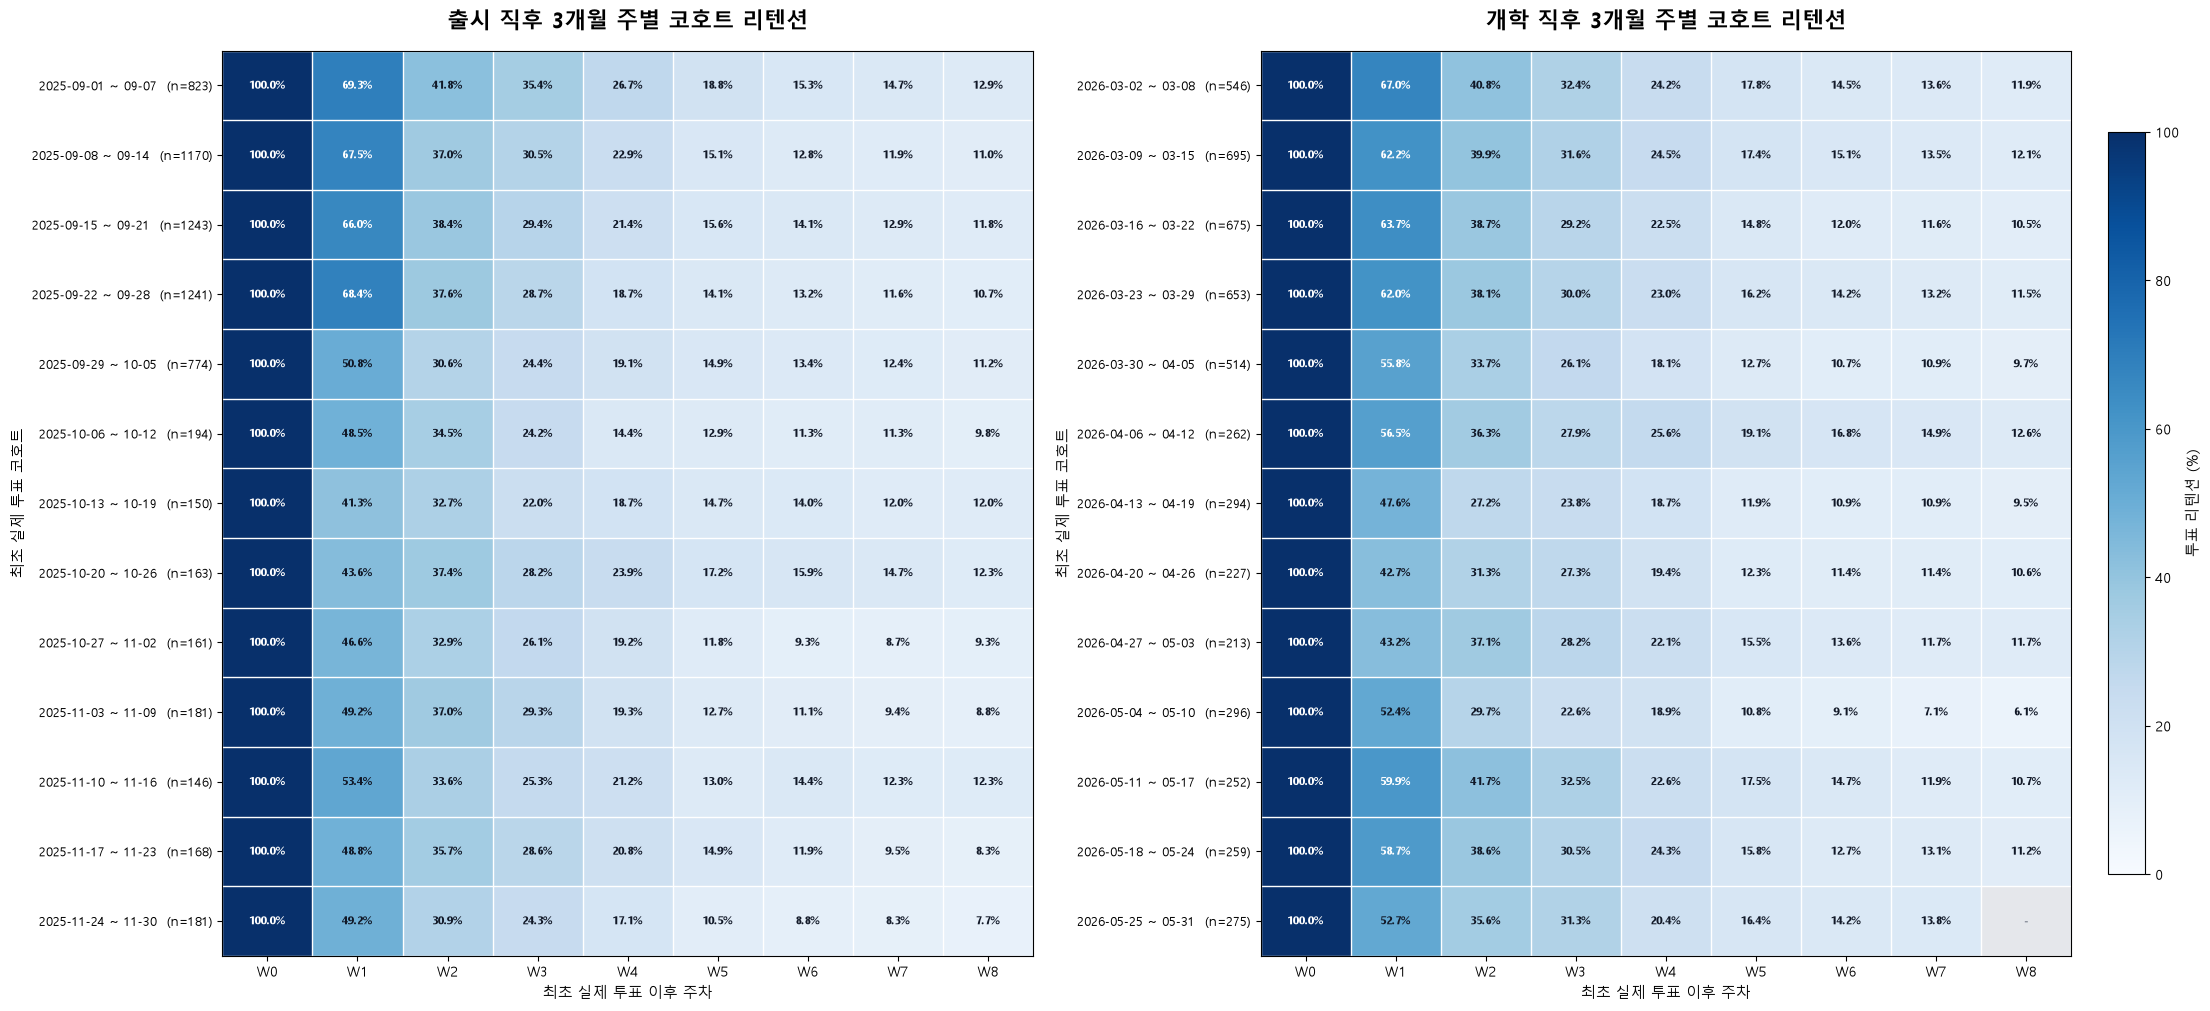

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform

# Windows·Mac 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

plot_df = df_seasonal_cohort.copy()

# 날짜형 변환
plot_df["cohort_week_start"] = pd.to_datetime(
    plot_df["cohort_week_start"]
)

plot_df["cohort_week_end"] = pd.to_datetime(
    plot_df["cohort_week_end"]
)

# 숫자형 변환
plot_df["retention_rate_percent"] = pd.to_numeric(
    plot_df["retention_rate_percent"],
    errors="coerce"
)

plot_df["cohort_user_count"] = pd.to_numeric(
    plot_df["cohort_user_count"],
    errors="coerce"
)

# 코호트 행 표시명
plot_df["cohort_label"] = (
    plot_df["cohort_week_start"].dt.strftime("%Y-%m-%d")
    + " ~ "
    + plot_df["cohort_week_end"].dt.strftime("%m-%d")
    + "  (n="
    + plot_df["cohort_user_count"]
      .astype("Int64")
      .astype(str)
    + ")"
)

# 일반적인 코호트 차트처럼 W0 포함
period_order = [
    "W0",
    "W1",
    "W2",
    "W3",
    "W4",
    "W5",
    "W6",
    "W7",
    "W8"
]

season_order = [
    "출시 직후",
    "개학 직후"
]

# 결측값은 회색으로 표시
cohort_cmap = plt.cm.Blues.copy()
cohort_cmap.set_bad(
    color="#E5E7EB"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(22, 10),
    constrained_layout=True
)

last_image = None

for ax, season in zip(
    axes,
    season_order
):
    season_df = (
        plot_df[
            plot_df["season_group"] == season
        ]
        .sort_values(
            [
                "cohort_week_start",
                "retention_period"
            ]
        )
    )

    # 코호트 행 순서
    cohort_order = (
        season_df[
            [
                "cohort_week_start",
                "cohort_label"
            ]
        ]
        .drop_duplicates()
        .sort_values("cohort_week_start")
        ["cohort_label"]
        .tolist()
    )

    # 히트맵용 피벗 테이블
    heatmap_data = (
        season_df
        .pivot(
            index="cohort_label",
            columns="retention_period",
            values="retention_rate_percent"
        )
        .reindex(
            index=cohort_order,
            columns=period_order
        )
    )

    # 숫자 행렬
    heatmap_values = (
        heatmap_data
        .astype(float)
        .to_numpy()
    )

    # 결측값 마스킹
    masked_values = np.ma.masked_invalid(
        heatmap_values
    )

    last_image = ax.imshow(
        masked_values,
        cmap=cohort_cmap,
        vmin=0,
        vmax=100,
        aspect="auto"
    )

    # X축: W0~W8
    ax.set_xticks(
        np.arange(len(period_order))
    )

    ax.set_xticklabels(
        period_order
    )

    # Y축: 주별 코호트
    ax.set_yticks(
        np.arange(len(cohort_order))
    )

    ax.set_yticklabels(
        cohort_order,
        fontsize=9
    )

    ax.set_title(
        f"{season} 3개월 주별 코호트 리텐션",
        fontsize=16,
        fontweight="bold",
        pad=16
    )

    ax.set_xlabel(
        "최초 실제 투표 이후 주차",
        fontsize=11
    )

    ax.set_ylabel(
        "최초 실제 투표 코호트",
        fontsize=11
    )

    # 셀 경계선
    ax.set_xticks(
        np.arange(
            -0.5,
            len(period_order),
            1
        ),
        minor=True
    )

    ax.set_yticks(
        np.arange(
            -0.5,
            len(cohort_order),
            1
        ),
        minor=True
    )

    ax.grid(
        which="minor",
        color="white",
        linestyle="-",
        linewidth=1
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    # 셀 안에 비율 표시
    for row_index in range(
        len(cohort_order)
    ):
        for column_index in range(
            len(period_order)
        ):
            value = heatmap_values[
                row_index,
                column_index
            ]

            # 관찰 기간이 부족한 셀
            if np.isnan(value):
                cell_text = "-"
                text_color = "#6B7280"

            else:
                cell_text = f"{value:.1f}%"

                # 배경색에 따른 글자색 조절
                if value >= 55:
                    text_color = "white"
                else:
                    text_color = "#111827"

            ax.text(
                column_index,
                row_index,
                cell_text,
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
                fontweight=(
                    "bold"
                    if not np.isnan(value)
                    else "normal"
                )
            )

# 두 그래프가 동일한 색상 기준을 공유
colorbar = fig.colorbar(
    last_image,
    ax=axes.ravel().tolist(),
    shrink=0.82,
    pad=0.02
)

colorbar.set_label(
    "투표 리텐션 (%)",
    fontsize=11
)

plt.show()

## 월별 코호트 리텐션 히트맵

2025-09-01부터 데이터 종료일까지 최초 투표월(`cohort_month`)을 기준으로 사용자를 월별 코호트로 묶고, 

W0~W8 구간의 재투표 리텐션을 코호트×기간 히트맵으로 그린다.

In [20]:
# 월별 11개 코호트
monthly_cohort_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS cohort_start_month,
    DATE '2026-07-23' AS data_end_date
),

-- W0는 최초 투표를 완료한 코호트 자체
-- W1부터는 서로 겹치지 않는 주 단위 구간
retention_periods AS (
  SELECT 0 AS period_order, 'W0' AS retention_period, 0 AS start_day, 0 AS end_day
  UNION ALL
  SELECT 1, 'W1', 1, 7
  UNION ALL
  SELECT 2, 'W2', 8, 14
  UNION ALL
  SELECT 3, 'W3', 15, 21
  UNION ALL
  SELECT 4, 'W4', 22, 28
  UNION ALL
  SELECT 5, 'W5', 29, 35
  UNION ALL
  SELECT 6, 'W6', 36, 42
  UNION ALL
  SELECT 7, 'W7', 43, 49
  UNION ALL
  SELECT 8, 'W8', 50, 56
),

-- 탈퇴하지 않았고 친구 5명 조건을 충족한 사용자
valid_unlocked_users AS (
  SELECT
    u.id AS user_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
    AND u.service_unlocked_at IS NOT NULL

    -- user_withdrawal에 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at,
    DATE(vi.voted_at, 'Asia/Seoul') AS vote_date
  FROM `ping-v2-503916.raw.vote_item` AS vi
  INNER JOIN valid_unlocked_users AS vu
    ON vi.user_id = vu.user_id
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표와 해당 세션
first_vote AS (
  SELECT
    user_id,

    ARRAY_AGG(
      STRUCT(
        voted_at,
        session_id
      )
      ORDER BY voted_at, session_id
      LIMIT 1
    )[OFFSET(0)] AS first_vote_info

  FROM actual_votes
  GROUP BY user_id
),

-- Retention 분석 기준 사용자
activated_users AS (
  SELECT
    user_id,
    first_vote_info.voted_at AS first_vote_at,
    first_vote_info.session_id AS first_session_id,

    DATE(
      first_vote_info.voted_at,
      'Asia/Seoul'
    ) AS first_vote_date,

    DATE_TRUNC(
      DATE(first_vote_info.voted_at, 'Asia/Seoul'),
      MONTH
    ) AS cohort_month

  FROM first_vote
  CROSS JOIN params
  WHERE DATE(first_vote_info.voted_at, 'Asia/Seoul')
        BETWEEN cohort_start_month AND data_end_date
),

-- 최초 투표와 다른 세션에서 발생한 재투표
return_votes AS (
  SELECT DISTINCT
    au.user_id,
    au.cohort_month,
    au.first_vote_date,
    av.vote_date AS return_vote_date,

    DATE_DIFF(
      av.vote_date,
      au.first_vote_date,
      DAY
    ) AS days_after_first_vote

  FROM activated_users AS au
  INNER JOIN actual_votes AS av
    ON av.user_id = au.user_id

    -- 최초 투표 세션 안에서 이어서 한 투표는 재방문으로 보지 않음
    AND av.session_id != au.first_session_id

    -- 최초 투표 다음 날 이후 행동만 포함
    AND av.vote_date > au.first_vote_date
),

-- 코호트 사용자 × 리텐션 기간
cohort_period_base AS (
  SELECT
    au.cohort_month,
    au.user_id,
    rp.period_order,
    rp.retention_period,
    rp.start_day,
    rp.end_day,
    p.data_end_date,

    -- 해당 월 전체 사용자가 해당 기간까지 관찰 가능한지 판정
    CASE
      WHEN rp.period_order = 0 THEN TRUE
      WHEN DATE_ADD(
             LAST_DAY(au.cohort_month, MONTH),
             INTERVAL rp.end_day DAY
           ) <= p.data_end_date
        THEN TRUE
      ELSE FALSE
    END AS is_observable

  FROM activated_users AS au
  CROSS JOIN retention_periods AS rp
  CROSS JOIN params AS p
),

-- 기간별 재투표 여부
user_retention AS (
  SELECT
    cpb.cohort_month,
    cpb.user_id,
    cpb.period_order,
    cpb.retention_period,
    cpb.start_day,
    cpb.end_day,
    cpb.data_end_date,
    cpb.is_observable,

    CASE
      -- W0는 코호트 기준 사용자이므로 모두 1
      WHEN cpb.period_order = 0 THEN 1

      -- 관찰기간이 부족하면 결과 없음
      WHEN NOT cpb.is_observable THEN NULL

      -- 해당 주차 구간에 재투표한 경우
      WHEN COUNTIF(
        rv.days_after_first_vote
        BETWEEN cpb.start_day AND cpb.end_day
      ) > 0 THEN 1

      ELSE 0
    END AS is_retained

  FROM cohort_period_base AS cpb
  LEFT JOIN return_votes AS rv
    ON rv.user_id = cpb.user_id
    AND rv.days_after_first_vote
        BETWEEN cpb.start_day AND cpb.end_day

  GROUP BY
    cpb.cohort_month,
    cpb.user_id,
    cpb.period_order,
    cpb.retention_period,
    cpb.start_day,
    cpb.end_day,
    cpb.data_end_date,
    cpb.is_observable
),

-- 월별 코호트 집계
cohort_result AS (
  SELECT
    cohort_month,
    period_order,
    retention_period,
    start_day,
    end_day,
    data_end_date,
    is_observable,

    COUNT(DISTINCT user_id) AS cohort_user_count,

    CASE
      WHEN is_observable
        THEN COUNT(DISTINCT user_id)
      ELSE NULL
    END AS eligible_user_count,

    CASE
      WHEN is_observable
        THEN COUNT(DISTINCT IF(is_retained = 1, user_id, NULL))
      ELSE NULL
    END AS retained_user_count

  FROM user_retention
  GROUP BY
    cohort_month,
    period_order,
    retention_period,
    start_day,
    end_day,
    data_end_date,
    is_observable
)

SELECT
  FORMAT_DATE('%Y-%m', cohort_month) AS cohort_label,
  cohort_month,
  retention_period,
  period_order,
  start_day,
  end_day,
  cohort_user_count,
  eligible_user_count,
  retained_user_count,

  CASE
    WHEN is_observable THEN
      ROUND(
        SAFE_DIVIDE(
          retained_user_count,
          eligible_user_count
        ) * 100,
        2
      )
    ELSE NULL
  END AS retention_rate_percent,

  CASE
    WHEN is_observable THEN
      ROUND(
        (
          1 - SAFE_DIVIDE(
            retained_user_count,
            eligible_user_count
          )
        ) * 100,
        2
      )
    ELSE NULL
  END AS churn_rate_percent,

  is_observable,

  CASE
    WHEN cohort_month = DATE_TRUNC(data_end_date, MONTH)
      THEN '부분 월'
    ELSE '완료 월'
  END AS cohort_status

FROM cohort_result
ORDER BY
  cohort_month,
  period_order
"""

In [21]:
cost(monthly_cohort_sql)

예상 스캔량: 394.157 MiB
예상 스캔량: 0.384919 GiB
월 1 TiB 무료 용량의 약 0.03758976%


0.3849191116169095

In [22]:
monthly_cohort_df = (
    bq.query(monthly_cohort_sql)
      .result()
      .to_dataframe()
)

monthly_cohort_df.head(20)

,cohort_label,cohort_month,retention_period,period_order,start_day,end_day,cohort_user_count,eligible_user_count,retained_user_count,retention_rate_percent,churn_rate_percent,is_observable,cohort_status
0,2025-09,2025-09-01,W0,0,0,0,4843,4843,4843,100.00,0.00,True,완료 월
1,2025-09,2025-09-01,W1,1,1,7,4843,4843,3237,66.84,33.16,True,완료 월
2,2025-09,2025-09-01,W2,2,8,14,4843,4843,1833,37.85,62.15,True,완료 월
3,2025-09,2025-09-01,W3,3,15,21,4843,4843,1456,30.06,69.94,True,완료 월
4,2025-09,2025-09-01,W4,4,22,28,4843,4843,1054,21.76,78.24,True,완료 월
5,2025-09,2025-09-01,W5,5,29,35,4843,4843,753,15.55,84.45,True,완료 월
6,2025-09,2025-09-01,W6,6,36,42,4843,4843,662,13.67,86.33,True,완료 월
7,2025-09,2025-09-01,W7,7,43,49,4843,4843,606,12.51,87.49,True,완료 월
8,2025-09,2025-09-01,W8,8,50,56,4843,4843,554,11.44,88.56,True,완료 월
9,2025-10,2025-10-01,W0,0,0,0,1025,1025,1025,100.00,0.00,True,완료 월


In [23]:
import pandas as pd

period_order = [
    "W0", "W1", "W2", "W3", "W4",
    "W5", "W6", "W7", "W8"
]

sentence_df = monthly_cohort_df.copy()

sentence_df["retention_rate_percent"] = pd.to_numeric(
    sentence_df["retention_rate_percent"],
    errors="coerce"
)

for cohort_label in sorted(sentence_df["cohort_label"].unique()):
    
    cohort_data = (
        sentence_df[
            sentence_df["cohort_label"] == cohort_label
        ]
        .set_index("retention_period")
        .reindex(period_order)
    )

    cohort_user_count = int(
        cohort_data["cohort_user_count"].dropna().iloc[0]
    )

    cohort_status = (
        cohort_data["cohort_status"].dropna().iloc[0]
    )

    retention_texts = []

    for period in period_order:
        rate = cohort_data.loc[
            period,
            "retention_rate_percent"
        ]

        if pd.isna(rate):
            retention_texts.append(
                f"{period} 관찰 불가"
            )
        else:
            retention_texts.append(
                f"{period} {float(rate):.2f}%"
            )

    print(
        f"[{cohort_label} 코호트 · {cohort_status}] "
        f"사용자 {cohort_user_count:,}명 | "
        + " · ".join(retention_texts)
    )

[2025-09 코호트 · 완료 월] 사용자 4,843명 | W0 100.00% · W1 66.84% · W2 37.85% · W3 30.06% · W4 21.76% · W5 15.55% · W6 13.67% · W7 12.51% · W8 11.44%
[2025-10 코호트 · 완료 월] 사용자 1,025명 | W0 100.00% · W1 45.46% · W2 33.07% · W3 25.17% · W4 19.02% · W5 14.83% · W6 13.27% · W7 12.29% · W8 11.12%
[2025-11 코호트 · 완료 월] 사용자 727명 | W0 100.00% · W1 49.52% · W2 34.11% · W3 26.82% · W4 19.67% · W5 12.52% · W6 11.28% · W7 9.90% · W8 9.35%
[2025-12 코호트 · 완료 월] 사용자 731명 | W0 100.00% · W1 41.72% · W2 29.96% · W3 22.30% · W4 17.37% · W5 12.45% · W6 10.67% · W7 9.17% · W8 8.62%
[2026-01 코호트 · 완료 월] 사용자 404명 | W0 100.00% · W1 39.60% · W2 31.93% · W3 26.24% · W4 19.80% · W5 17.08% · W6 15.10% · W7 15.59% · W8 15.35%
[2026-02 코호트 · 완료 월] 사용자 392명 | W0 100.00% · W1 37.50% · W2 30.10% · W3 26.53% · W4 21.17% · W5 15.82% · W6 14.54% · W7 13.27% · W8 12.24%
[2026-03 코호트 · 완료 월] 사용자 2,807명 | W0 100.00% · W1 63.09% · W2 39.05% · W3 30.42% · W4 23.01% · W5 16.32% · W6 13.86% · W7 12.93% · W8 11.51%
[2026-04 코호트 · 완료 월] 사용자 

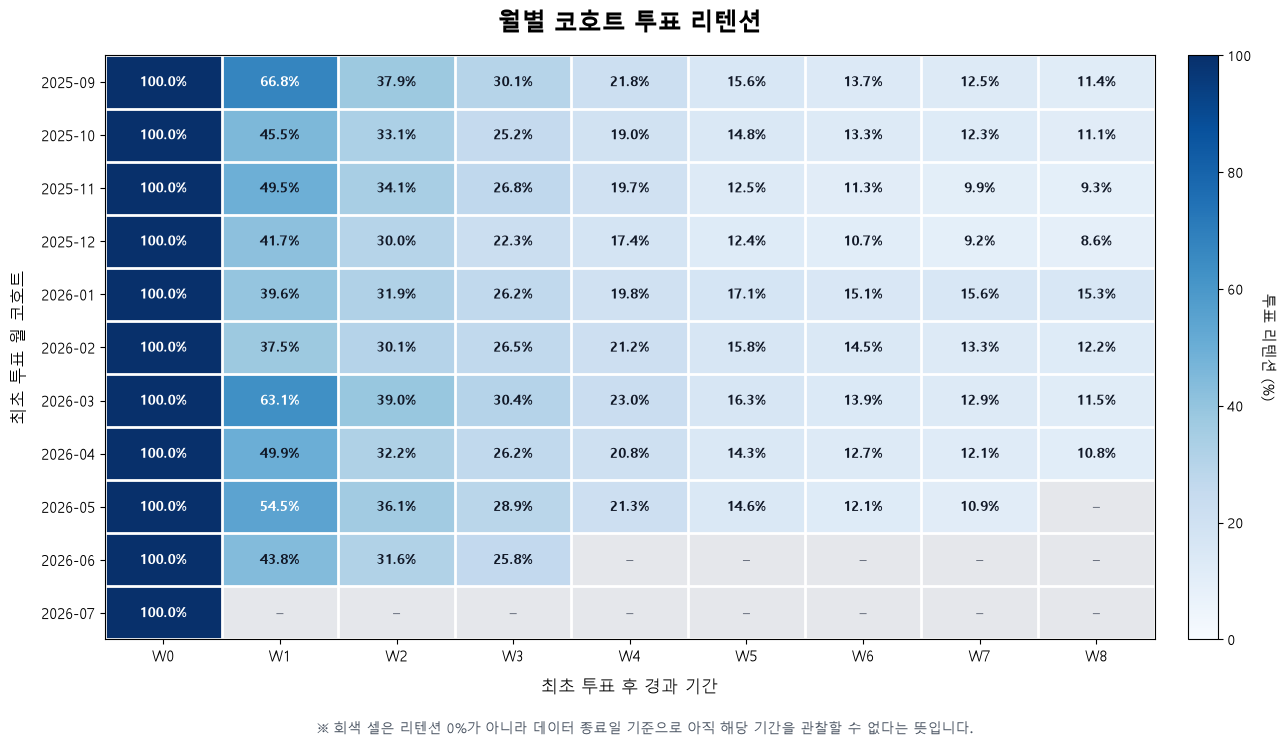

In [25]:
import platform
from copy import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트 설정
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 코호트·리텐션 기간 순서 설정
# =========================================================

period_order = [
    "W0", "W1", "W2", "W3", "W4",
    "W5", "W6", "W7", "W8"
]

cohort_order = sorted(
    monthly_cohort_df["cohort_label"]
    .dropna()
    .unique()
)


# =========================================================
# 3. 히트맵용 데이터 생성
# =========================================================

heatmap_df = (
    monthly_cohort_df
    .pivot_table(
        index="cohort_label",
        columns="retention_period",
        values="retention_rate_percent",
        aggfunc="first"
    )
    .reindex(
        index=cohort_order,
        columns=period_order
    )
)

# BigQuery 결과의 Decimal 또는 문자열을 숫자로 변환
heatmap_df = heatmap_df.apply(
    pd.to_numeric,
    errors="coerce"
)

# NumPy 배열로 변환
heatmap_values = heatmap_df.to_numpy(
    dtype=float
)

# NULL 값을 마스킹
# 관찰기간이 부족한 셀을 0%와 구분하기 위함
masked_values = np.ma.masked_invalid(
    heatmap_values
)


# =========================================================
# 4. 색상 설정
# =========================================================

# Matplotlib 구버전에서도 작동하도록 설정
cmap = copy(plt.cm.Blues)

# 관찰기간이 부족한 셀은 회색
cmap.set_bad(
    color="#E5E7EB"
)


# =========================================================
# 5. 히트맵 생성
# =========================================================

fig, ax = plt.subplots(
    figsize=(13, 7.5)
)

image = ax.imshow(
    masked_values,
    cmap=cmap,
    vmin=0,
    vmax=100,
    aspect="auto"
)


# =========================================================
# 6. X축·Y축 설정
# =========================================================

ax.set_xticks(
    np.arange(len(period_order))
)

ax.set_xticklabels(
    period_order,
    fontsize=11
)

ax.set_yticks(
    np.arange(len(cohort_order))
)

ax.set_yticklabels(
    cohort_order,
    fontsize=11
)

ax.set_xlabel(
    "최초 투표 후 경과 기간",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    "최초 투표 월 코호트",
    fontsize=12,
    labelpad=10
)

ax.set_title(
    "월별 코호트 투표 리텐션",
    fontsize=17,
    fontweight="bold",
    pad=18
)


# =========================================================
# 7. 셀 경계선 설정
# =========================================================

ax.set_xticks(
    np.arange(-0.5, len(period_order), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(cohort_order), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)


# =========================================================
# 8. 셀 안에 리텐션 수치 표시
# =========================================================

for row_idx in range(len(cohort_order)):
    for col_idx in range(len(period_order)):

        value = heatmap_values[
            row_idx,
            col_idx
        ]

        if np.isnan(value):
            # 관찰기간 부족
            label = "–"
            text_color = "#6B7280"
            font_weight = "normal"

        else:
            label = f"{value:.1f}%"

            # 배경색이 진한 셀은 흰색 글자 사용
            if value >= 50:
                text_color = "white"
            else:
                text_color = "#111827"

            font_weight = "bold"

        ax.text(
            col_idx,
            row_idx,
            label,
            ha="center",
            va="center",
            fontsize=10,
            fontweight=font_weight,
            color=text_color
        )


# =========================================================
# 9. 컬러바 설정
# =========================================================

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.035,
    pad=0.03
)

colorbar.set_label(
    "투표 리텐션 (%)",
    rotation=270,
    labelpad=18,
    fontsize=11
)


# =========================================================
# 10. 설명 문구
# =========================================================

fig.text(
    0.5,
    0.015,
    "※ 회색 셀은 리텐션 0%가 아니라 데이터 종료일 기준으로 아직 해당 기간을 관찰할 수 없다는 뜻입니다.",
    ha="center",
    fontsize=10,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.045, 1, 1]
)

plt.show()

## D0~D30 클래식(일 단위) 리텐션

2025-09-01부터 데이터 종료일 30일 전 사이에 최초 투표한 사용자를 대상으로, D0부터 D30까지 각 날짜에 '정확히 그 날짜'에 최초 세션이 아닌 곳에서 재투표했는지를 확인해(구간 누적이 아닌 일 단위 스냅샷) 리텐션 곡선을 그린다.

In [26]:
# 클래식 리텐션
classic_retention_sql = """
WITH
params AS (
  SELECT
    DATE '2025-09-01' AS analysis_start_date,
    DATE '2026-07-23' AS data_end_date,
    30 AS max_retention_day
),

-- D0부터 D30까지 생성
retention_days AS (
  SELECT
    day_number,
    CONCAT('D', CAST(day_number AS STRING)) AS retention_day
  FROM UNNEST(
    GENERATE_ARRAY(0, 30)
  ) AS day_number
),

-- 탈퇴하지 않았고 친구 5명 조건을 충족한 사용자
valid_unlocked_users AS (
  SELECT
    u.id AS user_id
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL
    AND u.service_unlocked_at IS NOT NULL

    -- 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS uw
      WHERE uw.user_id = u.id
        AND uw._source = 'local'
        AND uw._deleted_at IS NULL
    )
),

-- 유효 사용자의 실제 투표
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at,
    DATE(
      vi.voted_at,
      'Asia/Seoul'
    ) AS vote_date

  FROM `ping-v2-503916.raw.vote_item` AS vi

  INNER JOIN valid_unlocked_users AS vu
    ON vi.user_id = vu.user_id

  CROSS JOIN params AS p

  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL

    -- 데이터 종료일 이후 기록이 있더라도 제외
    AND DATE(
      vi.voted_at,
      'Asia/Seoul'
    ) <= p.data_end_date
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    session_id AS first_session_id,
    voted_at AS first_vote_at,
    vote_date AS first_vote_date

  FROM actual_votes

  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY user_id
    ORDER BY voted_at, session_id
  ) = 1
),

-- D30까지 전부 관찰할 수 있는 사용자만 포함
eligible_users AS (
  SELECT
    fv.user_id,
    fv.first_session_id,
    fv.first_vote_at,
    fv.first_vote_date

  FROM first_vote AS fv
  CROSS JOIN params AS p

  WHERE fv.first_vote_date
        BETWEEN p.analysis_start_date
        AND DATE_SUB(
          p.data_end_date,
          INTERVAL p.max_retention_day DAY
        )
),

-- 최초 투표와 다른 세션에서 발생한 재투표
return_votes AS (
  SELECT DISTINCT
    eu.user_id,
    av.vote_date AS return_vote_date,

    DATE_DIFF(
      av.vote_date,
      eu.first_vote_date,
      DAY
    ) AS days_after_first_vote

  FROM eligible_users AS eu

  INNER JOIN actual_votes AS av
    ON av.user_id = eu.user_id

    -- 최초 세션의 연속 투표 제외
    AND av.session_id != eu.first_session_id

    -- 최초 투표 다음 날부터 D30까지만 사용
    AND av.vote_date > eu.first_vote_date
    AND DATE_DIFF(
          av.vote_date,
          eu.first_vote_date,
          DAY
        ) BETWEEN 1 AND 30
),

-- 사용자와 D0~D30을 조합
user_day_retention AS (
  SELECT
    eu.user_id,
    rd.day_number,
    rd.retention_day,

    CASE
      -- D0는 최초 실제 투표 사용자이므로 모두 잔존
      WHEN rd.day_number = 0 THEN 1

      -- 정확히 해당 날짜에 다른 세션에서 재투표한 경우
      WHEN COUNTIF(
        rv.days_after_first_vote = rd.day_number
      ) > 0 THEN 1

      ELSE 0
    END AS is_retained

  FROM eligible_users AS eu

  CROSS JOIN retention_days AS rd

  LEFT JOIN return_votes AS rv
    ON rv.user_id = eu.user_id
    AND rv.days_after_first_vote = rd.day_number

  GROUP BY
    eu.user_id,
    rd.day_number,
    rd.retention_day
)

SELECT
  day_number,
  retention_day,

  COUNT(DISTINCT user_id) AS eligible_user_count,

  COUNT(
    DISTINCT IF(
      is_retained = 1,
      user_id,
      NULL
    )
  ) AS retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNT(
        DISTINCT IF(
          is_retained = 1,
          user_id,
          NULL
        )
      ),
      COUNT(DISTINCT user_id)
    ) * 100,
    2
  ) AS retention_rate_percent,

  ROUND(
    (
      1 - SAFE_DIVIDE(
        COUNT(
          DISTINCT IF(
            is_retained = 1,
            user_id,
            NULL
          )
        ),
        COUNT(DISTINCT user_id)
      )
    ) * 100,
    2
  ) AS non_return_rate_percent

FROM user_day_retention

GROUP BY
  day_number,
  retention_day

ORDER BY
  day_number
"""

In [27]:
cost(classic_retention_sql)

예상 스캔량: 394.157 MiB
예상 스캔량: 0.384919 GiB
월 1 TiB 무료 용량의 약 0.03758976%


0.3849191116169095

In [28]:
classic_retention_df = (
    bq.query(classic_retention_sql)
      .result()
      .to_dataframe()
)

classic_retention_df

,day_number,retention_day,eligible_user_count,retained_user_count,retention_rate_percent,non_return_rate_percent
0,0,D0,14010,14010,100.00,0.00
1,1,D1,14010,5990,42.76,57.24
2,2,D2,14010,5078,36.25,63.75
3,3,D3,14010,4736,33.80,66.20
4,4,D4,14010,4404,31.43,68.57
5,5,D5,14010,4237,30.24,69.76
6,6,D6,14010,4079,29.11,70.89
7,7,D7,14010,3958,28.25,71.75
8,8,D8,14010,3803,27.14,72.86
9,9,D9,14010,3660,26.12,73.88


In [29]:
eligible_user_count = int(
    classic_retention_df[
        "eligible_user_count"
    ].iloc[0]
)

print("[30일 클래식 투표 리텐션]")
print(
    f"분석 대상 사용자: "
    f"{eligible_user_count:,}명"
)
print(
    "분석 기준: 최초 실제 투표일을 D0로 설정하고, "
    "정확히 해당 날짜에 다른 세션에서 재투표했는지 확인"
)
print("-" * 65)

for _, row in classic_retention_df.iterrows():

    day = row["retention_day"]
    retained = int(
        row["retained_user_count"]
    )
    rate = float(
        row["retention_rate_percent"]
    )

    if row["day_number"] == 0:
        print(
            f"{day}: 기준 사용자 "
            f"{retained:,}명 ({rate:.2f}%)"
        )
    else:
        print(
            f"{day}: 재투표 사용자 "
            f"{retained:,}명 / "
            f"{eligible_user_count:,}명 "
            f"({rate:.2f}%)"
        )

[30일 클래식 투표 리텐션]
분석 대상 사용자: 14,010명
분석 기준: 최초 실제 투표일을 D0로 설정하고, 정확히 해당 날짜에 다른 세션에서 재투표했는지 확인
-----------------------------------------------------------------
D0: 기준 사용자 14,010명 (100.00%)
D1: 재투표 사용자 5,990명 / 14,010명 (42.76%)
D2: 재투표 사용자 5,078명 / 14,010명 (36.25%)
D3: 재투표 사용자 4,736명 / 14,010명 (33.80%)
D4: 재투표 사용자 4,404명 / 14,010명 (31.43%)
D5: 재투표 사용자 4,237명 / 14,010명 (30.24%)
D6: 재투표 사용자 4,079명 / 14,010명 (29.11%)
D7: 재투표 사용자 3,958명 / 14,010명 (28.25%)
D8: 재투표 사용자 3,803명 / 14,010명 (27.14%)
D9: 재투표 사용자 3,660명 / 14,010명 (26.12%)
D10: 재투표 사용자 3,532명 / 14,010명 (25.21%)
D11: 재투표 사용자 3,415명 / 14,010명 (24.38%)
D12: 재투표 사용자 3,321명 / 14,010명 (23.70%)
D13: 재투표 사용자 3,220명 / 14,010명 (22.98%)
D14: 재투표 사용자 3,095명 / 14,010명 (22.09%)
D15: 재투표 사용자 3,020명 / 14,010명 (21.56%)
D16: 재투표 사용자 2,863명 / 14,010명 (20.44%)
D17: 재투표 사용자 2,787명 / 14,010명 (19.89%)
D18: 재투표 사용자 2,626명 / 14,010명 (18.74%)
D19: 재투표 사용자 2,550명 / 14,010명 (18.20%)
D20: 재투표 사용자 2,480명 / 14,010명 (17.70%)
D21: 재투표 사용자 2,363명 / 14,010명 (16.87%)
D2

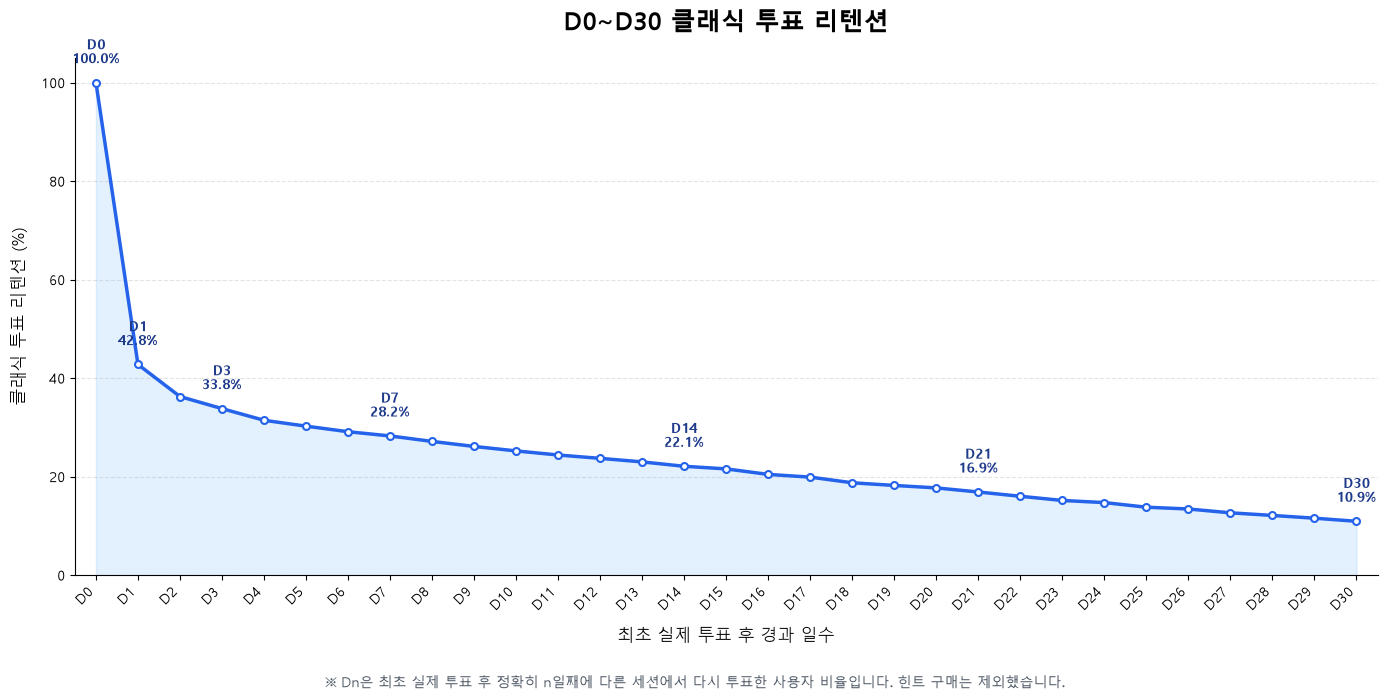

In [30]:
import platform

import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. 운영체제별 한글 폰트 설정
# =========================================================

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 2. 시각화용 데이터 정리
# =========================================================

plot_df = classic_retention_df.copy()

plot_df["day_number"] = pd.to_numeric(
    plot_df["day_number"],
    errors="coerce"
)

plot_df["retention_rate_percent"] = pd.to_numeric(
    plot_df["retention_rate_percent"],
    errors="coerce"
)

plot_df = plot_df.sort_values(
    "day_number"
)


# =========================================================
# 3. 클래식 리텐션 선 그래프
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)

ax.plot(
    plot_df["day_number"],
    plot_df["retention_rate_percent"],
    color="#2563EB",
    linewidth=2.5,
    marker="o",
    markersize=5,
    markerfacecolor="white",
    markeredgecolor="#2563EB",
    markeredgewidth=1.5
)

ax.fill_between(
    plot_df["day_number"],
    plot_df["retention_rate_percent"],
    0,
    color="#93C5FD",
    alpha=0.25
)


# =========================================================
# 4. 주요 날짜 라벨 표시
# =========================================================

important_days = [
    0, 1, 3, 7, 14, 21, 30
]

important_points = plot_df[
    plot_df["day_number"].isin(
        important_days
    )
]

for _, row in important_points.iterrows():

    day_number = int(
        row["day_number"]
    )

    rate = float(
        row["retention_rate_percent"]
    )

    ax.annotate(
        f"D{day_number}\n{rate:.1f}%",
        xy=(day_number, rate),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#1E3A8A"
    )


# =========================================================
# 5. 축과 제목 설정
# =========================================================

ax.set_title(
    "D0~D30 클래식 투표 리텐션",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "최초 실제 투표 후 경과 일수",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    "클래식 투표 리텐션 (%)",
    fontsize=12,
    labelpad=10
)

ax.set_xticks(
    range(0, 31)
)

ax.set_xticklabels(
    [f"D{day}" for day in range(0, 31)],
    rotation=45,
    ha="right"
)

ax.set_xlim(
    -0.5,
    30.5
)

ax.set_ylim(
    0,
    105
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================================================
# 6. 분석 기준 설명
# =========================================================

fig.text(
    0.5,
    0.01,
    "※ Dn은 최초 실제 투표 후 정확히 n일째에 다른 세션에서 다시 투표한 사용자 비율입니다. 힌트 구매는 제외했습니다.",
    ha="center",
    fontsize=10,
    color="#4B5563"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()